# Vom Ort zur datenbasierten Aussage

Dieses Notebook zeigt nicht nur Ergebnisse, sondern den Weg zu den Daten:
von der Fragestellung über Metadaten und Dateistrukturen bis zu Auswertungen und Visualisierungen.

Ausgangspunkt ist nicht das Werkzeug, sondern eine Frage.

**Arbeitsfassung: Dokumentierte Datenherkunft, Vollständigkeitsprüfung und Modellierung der Jahressummen.**
Die Abschnitte 7a–7c dokumentieren Quellen, Messbedingungen und Qualitätskennzeichen;
Abschnitt 10a fasst die verwendete Auswahl in einem Datensteckbrief zusammen.
Die Abschnitte 9 und 10 vergleichen die Messdaten mit einem vollständigen Kalender.
Fehlende Messwerte werden nicht durch null ersetzt. Die vergleichenden Auswertungen nutzen vollständig belegte Monate bzw. Jahre.
Das zusätzliche Blatt Jahressummen_Einstieg enthält für die Problematisierung auch Teilsummen. Ab Abschnitt 16 werden die vollständigen Jahressummen untersucht und mit zufälligen
Anordnungen genau derselben Werte verglichen. Kalenderlücken bleiben dabei erhalten.

**Start:** Die Zellen von oben nach unten ausführen. Benötigt werden Python mit
`requests`, `certifi`, `numpy`, `pandas`, `matplotlib` und für den Excel-Export `openpyxl`.
Der Datenabruf benötigt eine Internetverbindung. Gespeicherte Ergebnisse entstehen
im Unterordner `ausgabe` des aktuellen Arbeitsverzeichnisses.

## Fragestellung

Beispielfrage:
Wie hat sich der Niederschlag an einem Ort entwickelt und wie häufig treten Starkregentage auf?

Dazu müssen passende und verlässliche Realdaten zunächst gefunden, geprüft und aufbereitet werden.

## Überblick über den Datenweg

1. Datenquelle und Metadaten betrachten
2. Eine geeignete Station zum Ort finden
3. Verfügbare Dateien (historische und aktuelle Niederschlagsdaten) prüfen
4. Daten laden und aufbereiten
5. Optional: Export in Excel
6. Auswerten und visualisieren

## Station auswählen → Daten aufbereiten → untersuchen

1. **Station auswählen:** In der Excel-Stationsübersicht nach Name oder Bundesland filtern. Eine Station mit historischen Daten wählen und ihre Kennnummer in der ersten Codezelle bei `STATIONS_ID_WUNSCH` eintragen. Hannover-Herrenhausen (`02011`) ist voreingestellt.
2. **Daten aufbereiten:** Für die Arbeitsdateien `EXCEL_EXPORT = True` setzen und die Zellen von oben nach unten ausführen. Vor dem Messdatenabruf zeigt Abschnitt 4 Name, Kennnummer und verfügbaren Zeitraum der gewählten Station. Das Notebook lädt anschließend die Daten, prüft ihre Vollständigkeit und erzeugt die Excel-Dateien unter `ausgabe/excel`.
3. **Untersuchen:** Zuerst die beiden Datenspalten aus `Jahressummen_Einstieg` nach GeoGebra kopieren. Anschließend mögliche Datenlücken anhand von `Jahrespruefung` und `Fehlende_Tage` untersuchen. Die Modellierung im Notebook verwendet nur vollständige Jahre und berücksichtigt Kalenderlücken beim Zählen von Anstiegen.

Die Stationsübersicht wird in Abschnitt 3 unabhängig vom Auswertungsexport erzeugt. Mit `STATIONSUEBERSICHT_EXPORT = False` lässt sie sich abschalten. In einer Browserumgebung die erzeugten Excel-Dateien anschließend über die Dateiansicht herunterladen.


In [1]:
# Stations-ID aus stationsuebersicht_DWD.xlsx übernehmen (als Text in Anführungszeichen).
STATIONS_ID_WUNSCH = "02011"  # Hannover-Herrenhausen
# Nur wenn STATIONS_ID_WUNSCH = "": nach diesem Namen suchen.
ORT = "Hannover"
STATIONSUEBERSICHT_EXPORT = True  # Unabhängig vom Export der Auswertungen

# Dateien werden nur geschrieben, wenn die jeweilige Option aktiviert wird.
EXCEL_EXPORT = True
GRAFIKEN_SPEICHERN = True

# Wiederholungen und Startwert der Permutationssimulation
SIMULATIONEN = 100_000
SEED = 42

## Technische Vorbereitung

Die folgenden Hilfsfunktionen übernehmen technische Schritte wie das Laden von Text- und ZIP-Dateien.
Sie dienen der Infrastruktur und stehen nicht im Zentrum der inhaltlichen Untersuchung.

In [2]:
from pathlib import Path
from datetime import datetime, timezone
from urllib.parse import urlparse
import hashlib
import numpy as np
import io
import re
import zipfile
import requests
import certifi
import pandas as pd
import matplotlib.pyplot as plt

## 1. Datenquelle und Metadaten

Wir verwenden die täglichen Niederschlagsbeobachtungen des **Deutschen Wetterdienstes
(DWD), Climate Data Center (CDC)**, Produkt `daily/more_precip`.
Die [Datensatzbeschreibung, v24.3 (2024)](https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/daily/more_precip/BESCHREIBUNG_obsgermany-climate-daily-more_precip_de.pdf)
ist die Grundlage für die folgenden Erläuterungen. Diese Versionsangabe bezeichnet die
Dokumentation; die tatsächlich geladenen Daten werden separat mit URL, Abrufzeit und
Dateiprüfsumme erfasst.

Zunächst lesen wir die Stationsübersicht. Nach dem Laden der Archive dokumentieren die
Abschnitte **7a–7c** die ausgewählte Station, Messgröße, Messbedingungen und Qualitätskennzeichen.
Nach der Vollständigkeitsprüfung entsteht in **10a** ein Datensteckbrief der tatsächlichen Auswahl.

**Drei unterschiedliche Fragen:** Sind die benötigten Werte vorhanden? Welches Prüfverfahren
haben sie durchlaufen? Sind die Messbedingungen über den untersuchten Zeitraum vergleichbar?

In [3]:
# Basisadressen für historische und aktuelle Niederschlagsdaten des DWD
BASE_HIST = "https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/daily/more_precip/historical/"
BASE_REC  = "https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/daily/more_precip/recent/"

def get_text(url: str) -> str:
    r = requests.get(url, verify=certifi.where(), timeout=30)
    r.raise_for_status()
    return r.text

stations_url = BASE_HIST + "RR_Tageswerte_Beschreibung_Stationen.txt"
stations_text = get_text(stations_url)
stations_abruf_utc = datetime.now(timezone.utc).isoformat(timespec="seconds")

stations = pd.read_fwf(
    io.StringIO(stations_text),
    skiprows=2,
    names=[
        "STATIONS_ID", "VON_DATUM", "BIS_DATUM", "STATIONSHOEHE",
        "GEOBREITE", "GEOLAENGE", "STATIONSNAME", "BUNDESLAND", "ABGABE"
    ]
)

stations["STATIONS_ID"] = stations["STATIONS_ID"].astype(str).str.zfill(5)
display(stations.head())

,STATIONS_ID,VON_DATUM,BIS_DATUM,STATIONSHOEHE,GEOBREITE,GEOLAENGE,STATIONSNAME,BUNDESLAND,ABGABE
0,00001,19120101,19860630,478,47.8413,8.8493,Aach,Baden-Württemberg,Frei
1,00002,19510101,20061231,138,50.8066,6.0996,Aachen (Kläranlage),Nordrhein-Westfalen,Frei
2,00003,18910101,20110331,202,50.7827,6.0941,Aachen,Nordrhein-Westfalen,Frei
3,00004,19510101,19791031,243,50.7683,6.1207,Aachen-Brand,Nordrhein-Westfalen,Frei
4,00006,19821101,20260910,455,48.8361,10.0598,Aalen-Unterrombach,Baden-Württemberg,Frei


## 2. Eine Station auswählen

Für den direkten Einstieg ist **02011 (Hannover-Herrenhausen)** voreingestellt.
Für eine eigene Untersuchung eine Kennnummer aus **stationsuebersicht_DWD.xlsx**
in der ersten Zelle bei `STATIONS_ID_WUNSCH` eintragen und das Notebook erneut von oben ausführen.
Die Kennnummer hat Vorrang vor dem Ortsnamen. Sie wird gegen die DWD-Stationsliste geprüft.

Alternativ `STATIONS_ID_WUNSCH = ""` setzen und bei `ORT` einen Namensteil eingeben.
Die Suche zeigt passende Stationen. Der ausgewiesene Zeitraum garantiert keine lückenlose Reihe.


In [4]:
def stationskandidaten(stations, stations_id_wunsch, ort):
    kennung = str(stations_id_wunsch).strip()
    if kennung:
        if not re.fullmatch(r"[0-9]{1,5}", kennung):
            raise ValueError('Stations-ID mit bis zu fünf Ziffern angeben, z. B. "02011".')
        kennung = kennung.zfill(5)
        kandidaten = stations.loc[stations["STATIONS_ID"].eq(kennung)].copy()
        if kandidaten.empty:
            raise ValueError(f"Station {kennung} steht nicht in der geladenen DWD-Stationsliste. Bitte die Stationsübersicht prüfen.")
    else:
        if not str(ort).strip():
            raise ValueError("Bitte eine Stations-ID oder einen Ortsnamen eingeben.")
        kandidaten = stations.loc[stations["STATIONSNAME"].str.contains(str(ort).strip(), case=False, na=False, regex=False)].copy()
        if kandidaten.empty:
            raise ValueError(f"Keine Station zum Namen {ort!r} gefunden. Bitte die Excel-Stationsübersicht nutzen.")
    return kandidaten

stations_ort = stationskandidaten(stations, STATIONS_ID_WUNSCH, ORT)
display(stations_ort[["STATIONS_ID", "STATIONSNAME", "VON_DATUM", "BIS_DATUM"]])


,STATIONS_ID,STATIONSNAME,VON_DATUM,BIS_DATUM
1821,02011,Hannover-Herrenhausen,19310101,20260910


## 3. Welche Dateien gibt es wirklich?

Eine Station in der Metadatenliste ist noch keine gesicherte Datenbasis.
Deshalb wird nun geprüft, ob zu den gefundenen Stationen tatsächlich Dateien vorhanden sind.

Historische Daten sind für diesen Lernweg erforderlich. Aktuelle Daten ergänzen den Bestand, wenn sie verfügbar sind.

In [5]:
def files_for_station(station_id: str, files: list[str]) -> list[str]:
    return [f for f in files if f"_{station_id}_" in f]

hist_html = get_text(BASE_HIST)
rec_html = get_text(BASE_REC)

hist_files = sorted(set(re.findall(r'tageswerte_RR_\d{5}_\d{8}_\d{8}_hist\.zip', hist_html)))
rec_files = sorted(set(re.findall(r'tageswerte_RR_\d{5}_akt\.zip', rec_html)))

for sid in stations_ort["STATIONS_ID"]:
    hist_match = files_for_station(sid, hist_files)
    rec_match = files_for_station(sid, rec_files)

    print("\nStation:", sid)
    print("historical:", hist_match)
    print("recent    :", rec_match)

def erstelle_stationsuebersicht(stations, hist_files, rec_files):
    hist_ids = {name.split("_")[2] for name in hist_files}
    rec_ids = {name.split("_")[2] for name in rec_files}
    t = stations.copy()
    t["Historische Daten"] = t["STATIONS_ID"].isin(hist_ids).map({True: "Ja", False: "Nein"})
    t["Aktuelle Daten"] = t["STATIONS_ID"].isin(rec_ids).map({True: "Ja", False: "Nein"})
    t = t.rename(columns={"STATIONS_ID": "Stations-ID", "STATIONSNAME": "Stationsname",
                          "BUNDESLAND": "Bundesland", "VON_DATUM": "Beginn", "BIS_DATUM": "Ende",
                          "STATIONSHOEHE": "Höhe (m)", "GEOBREITE": "Breitengrad", "GEOLAENGE": "Längengrad"})
    for name in ["Beginn", "Ende"]:
        t[name] = pd.to_datetime(t[name].astype(str).str.replace(r"\.0$", "", regex=True), format="%Y%m%d", errors="coerce")
    return t[["Stations-ID", "Stationsname", "Bundesland", "Beginn", "Ende",
              "Historische Daten", "Aktuelle Daten", "Höhe (m)", "Breitengrad", "Längengrad"]].sort_values(
                  ["Stationsname", "Stations-ID"]).reset_index(drop=True)

stationsuebersicht = erstelle_stationsuebersicht(stations, hist_files, rec_files)
if STATIONSUEBERSICHT_EXPORT:
    from openpyxl.styles import Alignment, Font, PatternFill
    from openpyxl.worksheet.table import Table, TableStyleInfo
    ziel = Path("ausgabe") / "excel" / "stationsuebersicht_DWD.xlsx"
    ziel.parent.mkdir(parents=True, exist_ok=True)
    hinweise = pd.DataFrame([
        ("Benutzung", "Im Blatt Stationen nach Name oder Bundesland filtern. Stations-ID in der ersten Notebookzelle bei STATIONS_ID_WUNSCH eintragen und das Notebook von oben ausführen."),
        ("Voreinstellung", "02011: Hannover-Herrenhausen. Die Kennnummer hat Vorrang vor der optionalen Namenssuche."),
        ("Beginn und Ende", "Zeitraum laut DWD-Stationsübersicht. Er garantiert weder eine lückenlose Messreihe noch gültige Werte für einen bestimmten Tag."),
        ("Verfügbarkeit", "Ja bedeutet: Eine passende ZIP-Datei steht im geprüften Verzeichnis. Dies ist keine Prüfung der Vollständigkeit ihrer Messwerte. Für dieses Notebook sind historische Daten erforderlich; aktuelle Daten sind optional."),
        ("Räumliche Eignung", "Mehrere Stationen können zu einem Ort gehören. Lage, Stationsgeschichte und Messbedingungen vor einer Übertragung auf andere Orte prüfen."),
        ("Datenquelle", "Deutscher Wetterdienst, Climate Data Center; tägliche Niederschlagsbeobachtungen (daily/more_precip)."),
        ("Stationsübersicht", stations_url),
        ("Abruf Stationsübersicht (UTC)", stations_abruf_utc),
        ("Historisches Verzeichnis", BASE_HIST),
        ("Aktuelles Verzeichnis", BASE_REC),
        ("Verzeichnisse geprüft (UTC)", datetime.now(timezone.utc).isoformat(timespec="seconds")),
    ], columns=["Thema", "Erläuterung"])
    with pd.ExcelWriter(ziel, engine="openpyxl", datetime_format="DD.MM.YYYY") as writer:
        stationsuebersicht.to_excel(writer, sheet_name="Stationen", index=False)
        hinweise.to_excel(writer, sheet_name="Hinweise_Quellen", index=False)
        s = writer.sheets["Stationen"]
        s.freeze_panes = "C2"
        widths = [14, 44, 25, 15, 15, 19, 19, 14, 15, 15]
        for col, width in zip(s.columns, widths):
            s.column_dimensions[col[0].column_letter].width = width
        if len(stationsuebersicht):
            table = Table(displayName="DWDStationen", ref=f"A1:J{len(stationsuebersicht)+1}")
            table.tableStyleInfo = TableStyleInfo(name="TableStyleMedium2", showRowStripes=True)
            s.add_table(table)
        for row in s.iter_rows(min_row=2):
            row[0].number_format = "@"
            for cell in row[3:5]:
                cell.number_format = "dd.mm.yyyy"
        h = writer.sheets["Hinweise_Quellen"]
        h.column_dimensions["A"].width = 34
        h.column_dimensions["B"].width = 105
        h.freeze_panes = "A2"
        for row in h.iter_rows(min_row=2):
            for cell in row:
                cell.alignment = Alignment(wrap_text=True, vertical="top")
            h.row_dimensions[row[0].row].height = 60
        for sheet in [s, h]:
            sheet.row_dimensions[1].height = 32
            for cell in sheet[1]:
                cell.font = Font(bold=True, color="FFFFFF")
                cell.fill = PatternFill("solid", fgColor="24566B")
                cell.alignment = Alignment(wrap_text=True, vertical="center")
    print("Stationsübersicht exportiert:", ziel.resolve())



Station: 02011
historical: ['tageswerte_RR_02011_19310101_20251231_hist.zip']
recent    : ['tageswerte_RR_02011_akt.zip']
Stationsübersicht exportiert: /Users/reimund/Documents/Arbeit/Projekte/BigData/src/notebooks/ausgabe/excel/stationsuebersicht_DWD.xlsx


## 4. Verfügbarkeit prüfen und Auswahl bestätigen

Die gewählte Kennnummer muss historische Dateien besitzen. Aktuelle Dateien werden ergänzend
verwendet, wenn sie vorhanden sind; sie sind keine Voraussetzung für eine historische Untersuchung.
Bei einer Namenssuche wird eine Station mit beiden Beständen bevorzugt, andernfalls eine mit
historischen Daten. Name, Kennnummer und Zeitraum werden vor dem Messdatenabruf angezeigt.


In [6]:
def waehle_station(kandidaten, hist_files, rec_files):
    historisch = kandidaten.loc[kandidaten["STATIONS_ID"].map(lambda sid: bool(files_for_station(sid, hist_files)))].copy()
    if historisch.empty:
        raise ValueError("Für diese Auswahl sind keine historischen Niederschlagsdateien vorhanden. Bitte eine andere Station aus der Übersicht wählen.")
    mit_aktuellen = historisch.loc[historisch["STATIONS_ID"].map(lambda sid: bool(files_for_station(sid, rec_files)))]
    return (mit_aktuellen if not mit_aktuellen.empty else historisch).iloc[0].copy()

auswahl = waehle_station(stations_ort, hist_files, rec_files)
STATION_ID = str(auswahl["STATIONS_ID"])
auswahlbeschreibung = (
    f"Gezielte Auswahl über Stations-ID {STATION_ID}."
    if str(STATIONS_ID_WUNSCH).strip()
    else f"Namenssuche nach {ORT!r}; historische Daten erforderlich, aktuelle Daten bevorzugt."
)
# Alle nachfolgenden Namen, Exporte und Metadaten gehören zur tatsächlich gewählten Station.
ORT = str(auswahl["STATIONSNAME"])
print(auswahlbeschreibung)
display(auswahl[["STATIONS_ID", "STATIONSNAME", "VON_DATUM", "BIS_DATUM"]].to_frame("Ausgewählte Station"))
if not files_for_station(STATION_ID, rec_files):
    print("Keine aktuelle Datei vorhanden. Die Untersuchung verwendet den historischen Bestand.")


Gezielte Auswahl über Stations-ID 02011.


,Ausgewählte Station
STATIONS_ID,02011
STATIONSNAME,Hannover-Herrenhausen
VON_DATUM,19310101
BIS_DATUM,20260910


Die Auswahl erfolgt hier nicht nur nach dem Ortsnamen, sondern nach der tatsächlichen Verfügbarkeit der Dateien.
Damit wird sichtbar: Eine passende Station muss nicht nur existieren, sondern auch eine tragfähige Datenbasis für die Untersuchung liefern.

## 5. Welche Dateien werden verwendet?

Nach der Auswahl der Station wird nun bestimmt, welche konkrete historische und welche aktuelle Datei zu dieser Station gehören.
Erst damit ist klar, auf welche Datenbasis sich die weitere Untersuchung stützt.

In [7]:
hist_ort = files_for_station(STATION_ID, hist_files)
rec_ort = files_for_station(STATION_ID, rec_files)

if not hist_ort:
    raise ValueError(f"Keine historische Datei für Station {STATION_ID} gefunden.")

hist_file = hist_ort[0]
hist_url = BASE_HIST + hist_file

if rec_ort:
    rec_file = rec_ort[0]
    rec_url = BASE_REC + rec_file
else:
    rec_file = None
    rec_url = None

print("Historische Datei:", hist_file)
print("Aktuelle Datei   :", rec_file)

Historische Datei: tageswerte_RR_02011_19310101_20251231_hist.zip
Aktuelle Datei   : tageswerte_RR_02011_akt.zip


## 6. Aus einer Archivdatei wird ein Datensatz

Die ausgewählten Dateien liegen als ZIP-Archive vor.
Eine solche Datei ist noch keine direkt auswertbare Tabelle.

Deshalb müssen nun die eigentlichen Messdaten innerhalb des Archivs gefunden, eingelesen und in eine bearbeitbare Form überführt werden.

In [8]:
def get_bytes(url: str) -> bytes:
    r = requests.get(url, verify=certifi.where(), timeout=30)
    r.raise_for_status()
    return r.content


def load_rr_zip(url: str, bestand: str) -> dict:
    """Lade Messwerte, Herkunftsnachweis und originale Metadatentexte gemeinsam."""
    zip_bytes = get_bytes(url)
    abruf_utc = datetime.now(timezone.utc).isoformat(timespec="seconds")
    with zipfile.ZipFile(io.BytesIO(zip_bytes)) as zf:
        kandidaten = [name for name in zf.namelist() if name.startswith("produkt_") and name.endswith(".txt")]
        if len(kandidaten) != 1:
            raise ValueError("Erwartet wird genau eine Messdatendatei im Archiv.")
        txt_name = kandidaten[0]
        with zf.open(txt_name) as f:
            df = pd.read_csv(f, sep=";", na_values=["-999", "-999.0"])
        metadaten = {}
        for name in zf.namelist():
            if name.startswith("Metadaten_") and name.endswith(".txt"):
                raw = zf.read(name)
                try:
                    metadaten[name] = raw.decode("utf-8-sig")
                except UnicodeDecodeError:
                    metadaten[name] = raw.decode("latin1")

    df.columns = df.columns.str.strip()
    df["MESS_DATUM"] = pd.to_datetime(df["MESS_DATUM"], format="%Y%m%d", errors="raise")
    df["RS"] = pd.to_numeric(df["RS"], errors="coerce")
    # Fehlende Qualitätsangaben werden nicht als überprüfte Daten ausgegeben.
    if "QN_6" not in df:
        df["QN_6"] = float("nan")
    df["QN_6"] = pd.to_numeric(df["QN_6"], errors="coerce")
    df = df[["STATIONS_ID", "MESS_DATUM", "RS", "QN_6"]].copy()
    df = df.rename(columns={"MESS_DATUM": "datum", "RS": "niederschlag_mm"})
    ungueltig = df["niederschlag_mm"].lt(0) | df["niederschlag_mm"].isin([float("inf"), -float("inf")])
    df.loc[ungueltig, "niederschlag_mm"] = float("nan")
    df["datenbestand"] = bestand
    df["quelldatei"] = Path(urlparse(url).path).name
    nachweis = {
        "datenbestand": bestand, "url": url,
        "archivdatei": Path(urlparse(url).path).name, "produktdatei": txt_name,
        "abruf_utc": abruf_utc, "sha256": hashlib.sha256(zip_bytes).hexdigest(),
        "messzeilen": len(df), "erstes_referenzdatum": df["datum"].min(),
        "letztes_referenzdatum": df["datum"].max(),
    }
    return {"daten": df, "nachweis": nachweis, "metadaten": metadaten, "zip_bytes": zip_bytes}

## 7. Historische und aktuelle Daten zusammenführen

Für die ausgewählte Station werden nun die historischen und aktuellen Daten geladen.
Anschließend werden beide Bestände zu einer gemeinsamen Tabelle zusammengeführt.

In [9]:
archive = [load_rr_zip(hist_url, "historical")]
if rec_url is not None:
    archive.append(load_rr_zip(rec_url, "recent"))
quellennachweis = pd.DataFrame([a["nachweis"] for a in archive])
combined = pd.concat([a["daten"] for a in archive], ignore_index=True)

# Die gewählte Station wird gegen die tatsächlich geladenen Messzeilen geprüft.
if combined["STATIONS_ID"].isna().any() or not combined["STATIONS_ID"].astype(int).eq(int(STATION_ID)).all():
    raise ValueError("Die Stationsnummern im Archiv passen nicht zur ausgewählten Station.")

# Historische Daten stehen zuerst. Ihre Messwerte UND Qualitätskennzeichen haben Vorrang.
anzahl_entfernter_ueberschneidungen = int(combined.duplicated(["STATIONS_ID", "datum"]).sum())
combined = combined.drop_duplicates(subset=["STATIONS_ID", "datum"], keep="first")
combined = combined.sort_values("datum").reset_index(drop=True)
print("Entfernte doppelte Stations-/Datumszeilen:", anzahl_entfernter_ueberschneidungen)
print("Gesamtzeitraum:", combined["datum"].min(), "bis", combined["datum"].max())
display(combined.head())
display(combined.tail())

Entfernte doppelte Stations-/Datumszeilen: 297
Gesamtzeitraum: 1931-01-01 00:00:00 bis 2026-09-10 00:00:00


,STATIONS_ID,datum,niederschlag_mm,QN_6,datenbestand,quelldatei
0,2011,1931-01-01,6.5,5,historical,tageswerte_RR_02011_19310101_20251231_hist.zip
1,2011,1931-01-02,0.0,5,historical,tageswerte_RR_02011_19310101_20251231_hist.zip
2,2011,1931-01-03,5.8,5,historical,tageswerte_RR_02011_19310101_20251231_hist.zip
3,2011,1931-01-04,0.8,5,historical,tageswerte_RR_02011_19310101_20251231_hist.zip
4,2011,1931-01-05,4.2,5,historical,tageswerte_RR_02011_19310101_20251231_hist.zip


,STATIONS_ID,datum,niederschlag_mm,QN_6,datenbestand,quelldatei
34938,2011,2026-09-06,0.0,1,recent,tageswerte_RR_02011_akt.zip
34939,2011,2026-09-07,0.0,1,recent,tageswerte_RR_02011_akt.zip
34940,2011,2026-09-08,2.0,1,recent,tageswerte_RR_02011_akt.zip
34941,2011,2026-09-09,0.9,1,recent,tageswerte_RR_02011_akt.zip
34942,2011,2026-09-10,0.0,1,recent,tageswerte_RR_02011_akt.zip


Jetzt liegt erstmals ein bearbeitbarer Datensatz vor.
Er ist nicht einfach „gefunden“ worden, sondern das Ergebnis mehrerer Schritte:
Stationswahl, Dateiprüfung, Laden der Archivdateien, Bereinigung und Zusammenführung.

Erst auf dieser Grundlage können systematische Berechnungen und Visualisierungen folgen.

**Hinweis:** Der Datensatz kann anschließend auch in eine Excel-Datei exportiert werden.
Gerade in einem vertrauten Excel-Umfeld wird sichtbar, welche Vorarbeit nötig ist, damit Realdaten überhaupt rechnerisch bearbeitbar werden.

### 7a. Datenherkunft und Messgröße dokumentieren

`RS` ist die tägliche Niederschlagshöhe in **Millimetern**, einschließlich der als Wasserhöhe
erfassten festen Niederschläge. Wir bilden die Jahressumme durch Addition der Tageswerte,
die der DWD mit einem Referenzdatum (`MESS_DATUM`) im jeweiligen Kalenderjahr versieht.
**Der Messzeitraum eines Tageswerts ist nicht automatisch 0–24 Uhr.** Die stationsbezogenen
Parameter-Metadaten zeigen den jeweiligen Zeitbezug; wir verschieben die Datumszuordnung nicht.

Die Tabelle nennt für jedes geladene Archiv die genaue Quelle und den Abrufzeitpunkt in UTC.
Das letzte Referenzdatum beschreibt den Datenumfang; es ist nicht das Abrufdatum.
Ein späterer Abruf derselben URL kann einen anderen Inhalt liefern. Die SHA-256-Prüfsumme
identifiziert den konkreten Dateiinhalt. Beim Excel-Export werden die geladenen ZIP-Archive
und die gelesene Stationsübersicht zusätzlich unter `ausgabe/quellen` gesichert.

In [10]:
display(quellennachweis)
print("Stationsübersicht:", stations_url)
print("Abruf der Stationsübersicht (UTC):", stations_abruf_utc)

,datenbestand,url,archivdatei,produktdatei,abruf_utc,sha256,messzeilen,erstes_referenzdatum,letztes_referenzdatum
0,historical,https://opendata.dwd.de/climate_environment/CD...,tageswerte_RR_02011_19310101_20251231_hist.zip,produkt_nieder_tag_19310101_20251231_02011.txt,2026-09-11T11:58:56+00:00,52eed26cb303d75bdc00b6d83ef3d234ae712a2361ae22...,34690,1931-01-01,2025-12-31
1,recent,https://opendata.dwd.de/climate_environment/CD...,tageswerte_RR_02011_akt.zip,produkt_nieder_tag_20250310_20260910_02011.txt,2026-09-11T11:58:56+00:00,6735f66a6b1590e2d59e9c03c3b9cd9d9e39848e8cd2b7...,550,2025-03-10,2026-09-10


Stationsübersicht: https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/daily/more_precip/historical/RR_Tageswerte_Beschreibung_Stationen.txt
Abruf der Stationsübersicht (UTC): 2026-09-11T11:58:54+00:00


### 7b. Wetterstation und Messbedingungen

Der Ortsname allein bestimmt noch keine repräsentative Reihe für das gesamte Stadtgebiet.
Bei der optionalen Namenssuche werden historische Daten vorausgesetzt und aktuelle Daten bevorzugt.
Die voreingestellte oder selbst eingetragene Stations-ID wählt dagegen gezielt eine Station aus.
Beides ist kein Nachweis meteorologischer Eignung.
Die ausgewählte Station wird unten mit Nummer und Name ausgewiesen.

Wir lesen aus den verfügbaren Archiven die Metadaten zu Lage, Niederschlagsmessgerät und Parameter
`RS`. Die Herkunft jeder Zeile bleibt sichtbar, auch wenn beide Archive dieselben Angaben
enthalten. Dokumentierte Änderungen sind Anlass zur Prüfung der Vergleichbarkeit; aus ihnen
allein lässt sich weder ein Messfehler noch dessen Größe ableiten. Eine Homogenisierung der
Messreihe wird in diesem Notebook nicht durchgeführt.

**Prüfauftrag:** Welche Änderungen von Koordinaten, Geräten oder Zeitbezug findet ihr?
Warum garantiert eine gleichbleibende Stationsnummer keine unveränderten Messbedingungen?

In [11]:
def metatabelle(text):
    """Lese Datenzeilen unter der ersten Kopfzeile; Legenden bleiben im Originalarchiv."""
    zeilen = text.splitlines()
    if not zeilen:
        return pd.DataFrame()
    daten = [z for z in zeilen[1:] if re.match(r"^\s*\d+\s*;", z)]
    if not daten:
        return pd.DataFrame()
    tabelle = pd.read_csv(io.StringIO("\n".join([zeilen[0]] + daten)), sep=";", dtype=str)
    tabelle.columns = tabelle.columns.str.strip()
    return tabelle.loc[:, ~tabelle.columns.str.match(r"^(Unnamed:|eor$)")].apply(lambda s: s.str.strip())


metadaten_tabellen = {}
for art, muster in [
    ("Lage", "Metadaten_Geographie_"),
    ("Geraete", "Metadaten_Geraete_Niederschlagshoehe_"),
    ("Parameter_RS", "Metadaten_Parameter_"),
]:
    teile = []
    for archiv in archive:
        for datei, text in archiv["metadaten"].items():
            if datei.startswith(muster):
                t = metatabelle(text)
                if art == "Parameter_RS" and "Parameter" in t:
                    t = t.loc[t["Parameter"] == "RS"].copy()
                if not t.empty:
                    t.insert(0, "datenbestand", archiv["nachweis"]["datenbestand"])
                    t.insert(1, "metadatendatei", datei)
                    teile.append(t)
    metadaten_tabellen[art] = pd.concat(teile, ignore_index=True) if teile else pd.DataFrame()

stationsname = str(auswahl["STATIONSNAME"])
print("Ausgewählte Station:", STATION_ID, stationsname)
for art, tabelle in metadaten_tabellen.items():
    print("Metadaten:", art)
    if tabelle.empty:
        print("Keine entsprechenden Angaben im geladenen Archiv gefunden; Vergleichbarkeit bleibt zu prüfen.")
    else:
        display(tabelle)

Ausgewählte Station: 02011 Hannover-Herrenhausen
Metadaten: Lage


,datenbestand,metadatendatei,Stations_id,Stationshoehe,Geogr.Breite,Geogr.Laenge,von_datum,bis_datum,Stationsname
0,historical,Metadaten_Geographie_02011.txt,2011,50.00,52.3953,9.6684,19110601,19750630,Hannover-Herrenhausen
1,historical,Metadaten_Geographie_02011.txt,2011,50.00,52.3967,9.6615,19750701,20041231,Hannover-Herrenhausen
2,historical,Metadaten_Geographie_02011.txt,2011,50.00,52.3965,9.6629,20050101,,Hannover-Herrenhausen
3,recent,Metadaten_Geographie_02011.txt,2011,50.00,52.3953,9.6684,19110601,19750630,Hannover-Herrenhausen
4,recent,Metadaten_Geographie_02011.txt,2011,50.00,52.3967,9.6615,19750701,20041231,Hannover-Herrenhausen
5,recent,Metadaten_Geographie_02011.txt,2011,50.00,52.3965,9.6629,20050101,,Hannover-Herrenhausen


Metadaten: Geraete


,datenbestand,metadatendatei,Stations_ID,Stationsname,Geo. Laenge [Grad],Geo. Breite [Grad],Stationshoehe [m],Geberhoehe ueber Grund [m],Von_Datum,Bis_Datum,Geraetetyp Name,Messverfahren
0,historical,Metadaten_Geraete_Niederschlagshoehe_02011.txt,2011,Hannover-Herrenhausen,9.67,52.4,50,1,19310101,19750630,Hellmann,"Niederschlagsmenge, konv."
1,historical,Metadaten_Geraete_Niederschlagshoehe_02011.txt,2011,Hannover-Herrenhausen,9.66,52.4,50,1,19750701,20041231,Hellmann,"Niederschlagsmenge, konv."
2,historical,Metadaten_Geraete_Niederschlagshoehe_02011.txt,2011,Hannover-Herrenhausen,9.66,52.4,50,1,20050101,20200401,PLUVIO,"Niederschlagsmenge, elektr."
3,historical,Metadaten_Geraete_Niederschlagshoehe_02011.txt,2011,Hannover-Herrenhausen,9.66,52.4,50,1,20200402,20260419,"rain[e]H3, Wägetechnologie","Niederschlagsmenge, elektr."
4,recent,Metadaten_Geraete_Niederschlagshoehe_02011.txt,2011,Hannover-Herrenhausen,9.67,52.4,50,1,19310101,19750630,Hellmann,"Niederschlagsmenge, konv."
5,recent,Metadaten_Geraete_Niederschlagshoehe_02011.txt,2011,Hannover-Herrenhausen,9.66,52.4,50,1,19750701,20041231,Hellmann,"Niederschlagsmenge, konv."
6,recent,Metadaten_Geraete_Niederschlagshoehe_02011.txt,2011,Hannover-Herrenhausen,9.66,52.4,50,1,20050101,20200401,PLUVIO,"Niederschlagsmenge, elektr."
7,recent,Metadaten_Geraete_Niederschlagshoehe_02011.txt,2011,Hannover-Herrenhausen,9.66,52.4,50,1,20200402,20260910,"rain[e]H3, Wägetechnologie","Niederschlagsmenge, elektr."


Metadaten: Parameter_RS


,datenbestand,metadatendatei,Stations_ID,Von_Datum,Bis_Datum,Stationsname,Parameter,Parameterbeschreibung,Einheit,Datenquelle (Strukturversion=SV),Zusatz-Info,Besonderheiten,Literaturhinweis
0,historical,Metadaten_Parameter_nieder_tag_02011.txt,2011,19310101,20041231,Hannover-Herrenhausen,RS,tgl. Niederschlagshoehe Messnetz 6,mm,Niederschlagsdaten aus Niederschlagsroutine de...,NBL:07:00-07:00 FT. GZ (bis 1990) sonst 07:30...,NaN,NaN
1,historical,Metadaten_Parameter_nieder_tag_02011.txt,2011,20050101,20260418,Hannover-Herrenhausen,RS,tgl. Niederschlagshoehe Messnetz 6,mm,Niederschlagsdaten aus Niederschlagsroutine na...,06:00 - 06 FT. UTC (05:51-05:50 FT.UTC),NaN,NaN
2,recent,Metadaten_Parameter_nieder_tag_02011.txt,2011,19310101,20041231,Hannover-Herrenhausen,RS,tgl. Niederschlagshoehe Messnetz 6,mm,Niederschlagsdaten aus Niederschlagsroutine de...,NBL:07:00-07:00 FT. GZ (bis 1990) sonst 07:30...,NaN,NaN
3,recent,Metadaten_Parameter_nieder_tag_02011.txt,2011,20050101,20260910,Hannover-Herrenhausen,RS,tgl. Niederschlagshoehe Messnetz 6,mm,Niederschlagsdaten aus Niederschlagsroutine na...,06:00 - 06 FT. UTC (05:51-05:50 FT.UTC),NaN,NaN


### 7c. Qualitätskennzeichen erhalten und einordnen

`QN_6` kennzeichnet das angewandte Prüfverfahren. Die Zahl ist keine Schulnote und keine
lineare Skala der Messgenauigkeit. Historische Prüfverfahren unterscheiden sich von neueren.
Nach der DWD-Beschreibung war bis einschließlich 1980 höchstens QN 5 möglich.
Ein pauschaler Filter „nur QN 10“ würde daher große Teile der langen Reihe ausschließen.

`historical` und `recent` unterscheiden sich im Bearbeitungsstand; aktuelle Daten können noch
revidiert werden. Bei Überschneidungen verwenden wir den historischen Eintrag. Dennoch wird
der tatsächlich vorhandene Code stets gesondert dokumentiert.

**Unsere Entscheidung:** Kein zusätzlicher Filter nach `QN_6`. Fehlende oder unbekannte Codes
bleiben sichtbar. Die anschließende Vollständigkeitsprüfung bewertet den Messwert und die
Datumsabdeckung, nicht den Prüfcode. Die Übersicht zählt nur die nach Zusammenführung
beibehaltenen Zeilen, damit überlappende Daten nicht doppelt in die Statistik eingehen.

**Arbeitsauftrag:** Welche Codes treten in welchen Jahren auf? Warum ist „vollständig“
nicht dasselbe wie „unter vergleichbaren Bedingungen gemessen“?

Grundlage für die folgenden Kurzfassungen: [DWD-Datensatzbeschreibung, Qualitätsinformation](https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/daily/more_precip/BESCHREIBUNG_obsgermany-climate-daily-more_precip_de.pdf).

In [12]:
qn_bedeutungen = {
    1: "Formale Kontrolle", 2: "Prüfung mit individuell festgelegten Kriterien",
    3: "Automatische Prüfung und Korrektur", 5: "Historisches, subjektives Prüfverfahren",
    7: "Geprüft und gepflegt, Korrektur noch offen", 8: "Qualitätssicherung außerhalb der Routine",
    9: "Korrekturen nicht für alle Parameter abgeschlossen", 10: "Prüfung und Korrektur abgeschlossen",
}
qn_legende = pd.DataFrame(qn_bedeutungen.items(), columns=["QN_6", "erlaeuterung"])
qualitaetsdaten = combined.assign(jahr=combined["datum"].dt.year)
qualitaetsdaten["erlaeuterung"] = qualitaetsdaten["QN_6"].map(qn_bedeutungen).fillna("Code nicht in dieser Legende beschrieben")
qualitaetsdaten.loc[qualitaetsdaten["QN_6"].isna(), "erlaeuterung"] = "Keine lesbare Qualitätsangabe"
qualitaetsuebersicht = qualitaetsdaten.groupby(
    ["datenbestand", "QN_6", "erlaeuterung"], dropna=False, as_index=False
).agg(messzeilen=("datum", "size"), gueltige_werte=("niederschlag_mm", "count"),
      erstes_datum=("datum", "min"), letztes_datum=("datum", "max"))
# Der Zeitraum zwischen erstem und letztem Datum muss nicht durchgehend denselben Code haben.
qualitaet_pro_jahr = qualitaetsdaten.groupby(
    ["jahr", "datenbestand", "QN_6", "erlaeuterung"], dropna=False, as_index=False
).agg(messzeilen=("datum", "size"), gueltige_werte=("niederschlag_mm", "count"))
display(qn_legende)
display(qualitaetsuebersicht)
print("Jahresweise Aufschlüsselung (letzte zwölf Zeilen; vollständig im Export):")
display(qualitaet_pro_jahr.tail(12))

,QN_6,erlaeuterung
0,1,Formale Kontrolle
1,2,Prüfung mit individuell festgelegten Kriterien
2,3,Automatische Prüfung und Korrektur
3,5,"Historisches, subjektives Prüfverfahren"
4,7,"Geprüft und gepflegt, Korrektur noch offen"
5,8,Qualitätssicherung außerhalb der Routine
6,9,Korrekturen nicht für alle Parameter abgeschlo...
7,10,Prüfung und Korrektur abgeschlossen


,datenbestand,QN_6,erlaeuterung,messzeilen,gueltige_werte,erstes_datum,letztes_datum
0,historical,3,Automatische Prüfung und Korrektur,396,396,2024-12-01,2025-12-31
1,historical,5,"Historisches, subjektives Prüfverfahren",18263,18263,1931-01-01,1980-12-31
2,historical,9,Korrekturen nicht für alle Parameter abgeschlo...,12379,12379,1991-01-01,2024-11-30
3,historical,10,Prüfung und Korrektur abgeschlossen,3652,3652,1981-01-01,1990-12-31
4,recent,1,Formale Kontrolle,73,73,2026-06-30,2026-09-10
5,recent,3,Automatische Prüfung und Korrektur,180,180,2026-01-01,2026-06-29


Jahresweise Aufschlüsselung (letzte zwölf Zeilen; vollständig im Export):


,jahr,datenbestand,QN_6,erlaeuterung,messzeilen,gueltige_werte
86,2017,historical,9,Korrekturen nicht für alle Parameter abgeschlo...,365,365
87,2018,historical,9,Korrekturen nicht für alle Parameter abgeschlo...,365,365
88,2019,historical,9,Korrekturen nicht für alle Parameter abgeschlo...,365,365
89,2020,historical,9,Korrekturen nicht für alle Parameter abgeschlo...,366,366
90,2021,historical,9,Korrekturen nicht für alle Parameter abgeschlo...,365,365
91,2022,historical,9,Korrekturen nicht für alle Parameter abgeschlo...,365,365
92,2023,historical,9,Korrekturen nicht für alle Parameter abgeschlo...,357,357
93,2024,historical,3,Automatische Prüfung und Korrektur,31,31
94,2024,historical,9,Korrekturen nicht für alle Parameter abgeschlo...,335,335
95,2025,historical,3,Automatische Prüfung und Korrektur,365,365


## 8. Zeitinformationen ergänzen

Der Datensatz enthält bisher Tageswerte mit Datum.
Für weitere Auswertungen werden nun Jahr, Monat und Tag als eigene Spalten ergänzt.

Zusätzlich wird erfasst, an welchen Tagen mindestens 20 mm Niederschlag gefallen sind.
Solche Tage werden hier als Starkregentage gezählt.

Für fehlende Messwerte bleibt auch die Aussage „mindestens 20 mm“ offen.
Sie werden weder als trockene Tage noch als Tage unterhalb des Schwellenwerts gezählt.


In [13]:
combined["jahr"] = combined["datum"].dt.year
combined["monat"] = combined["datum"].dt.month
combined["tag"] = combined["datum"].dt.day

combined["starkregen_20mm"] = (
    combined["niederschlag_mm"].ge(20).astype("boolean")
    .where(combined["niederschlag_mm"].notna())
)

display(combined.head())

,STATIONS_ID,datum,niederschlag_mm,QN_6,datenbestand,quelldatei,jahr,monat,tag,starkregen_20mm
0,2011,1931-01-01,6.5,5,historical,tageswerte_RR_02011_19310101_20251231_hist.zip,1931,1,1,False
1,2011,1931-01-02,0.0,5,historical,tageswerte_RR_02011_19310101_20251231_hist.zip,1931,1,2,False
2,2011,1931-01-03,5.8,5,historical,tageswerte_RR_02011_19310101_20251231_hist.zip,1931,1,3,False
3,2011,1931-01-04,0.8,5,historical,tageswerte_RR_02011_19310101_20251231_hist.zip,1931,1,4,False
4,2011,1931-01-05,4.2,5,historical,tageswerte_RR_02011_19310101_20251231_hist.zip,1931,1,5,False


## 9. Die Messdaten mit einem vollständigen Kalender vergleichen

**Erst überlegen:** Ist ein Jahr vollständig, wenn in jedem der zwölf Monate
mindestens eine Messung vorhanden ist? Was muss eine bessere Prüfung leisten?

Wir legen für jedes Jahr des Datenbestands einen vollständigen Kalender an.
Damit werden auch Tage sichtbar, deren Zeilen in der Quelldatei ganz fehlen.
Ein gültiger Tageswert muss als endliche, nichtnegative Niederschlagsmenge vorliegen.
Diese formale Prüfung ersetzt keine meteorologische Qualitätsprüfung.

Die Prüftabellen unterscheiden:

- **Tage erwartet:** alle Kalendertage des Monats bzw. Jahres, einschließlich Schalttagen.
- **Tage gültig:** Tage mit gültigem Niederschlagswert.
- **Tage ohne gültigen Wert:** Differenz zwischen erwartet und gültig.
- **Fehlt im Datenzeitraum:** Tage ohne gültigen Wert zwischen erster und letzter Datenzeile.
- **Außerhalb des Datenzeitraums:** Randtage vor der ersten bzw. nach der letzten Datenzeile.

Die letzte Kategorie umfasst beispielsweise den noch nicht abgedeckten Rest des
laufenden Jahres. Sie ist kein Nachweis eines Messausfalls. Auch vollständig fehlende
Monate oder Jahre innerhalb des Datenzeitraums werden erfasst.


In [14]:
def pruefe_vollstaendigkeit(daten):
    """Vergleiche Tageswerte genau einer Station mit vollständigen Kalenderjahren."""
    daten = daten.copy()
    if daten.empty:
        raise ValueError("Es liegen keine Tagesdaten zur Prüfung vor.")
    if daten["STATIONS_ID"].isna().any() or daten["STATIONS_ID"].nunique() != 1:
        raise ValueError("Die Prüfung benötigt genau eine eindeutig bestimmte Station.")

    daten["datum"] = pd.to_datetime(daten["datum"], errors="raise")
    if daten["datum"].isna().any():
        raise ValueError("Eine Datenzeile enthält kein Datum.")
    if not daten["datum"].eq(daten["datum"].dt.normalize()).all():
        raise ValueError("Erwartet werden Tagesdaten ohne Uhrzeit.")
    if daten["datum"].duplicated().any():
        raise ValueError("Ein Datum kommt mehrfach vor. Zuerst Duplikate klären.")

    werte = pd.to_numeric(daten["niederschlag_mm"], errors="coerce")
    ungueltig = werte.lt(0) | werte.isin([float("inf"), float("-inf")])
    daten["niederschlag_mm"] = werte.mask(ungueltig)
    erstes_datum = daten["datum"].min()
    letztes_datum = daten["datum"].max()

    kalender = pd.date_range(
        f"{erstes_datum.year}-01-01", f"{letztes_datum.year}-12-31", name="datum"
    )
    raster = daten.set_index("datum")[["niederschlag_mm"]].reindex(kalender)
    raster["messzeile_vorhanden"] = raster.index.isin(daten["datum"])
    raster["im_datenzeitraum"] = (
        (raster.index >= erstes_datum) & (raster.index <= letztes_datum)
    )
    raster["gueltig"] = raster["niederschlag_mm"].notna()
    raster["fehlt_im_datenzeitraum"] = raster["im_datenzeitraum"] & ~raster["gueltig"]
    raster["ausserhalb_datenzeitraum"] = ~raster["im_datenzeitraum"]
    raster["jahr"] = raster.index.year
    raster["monat"] = raster.index.month
    raster = raster.reset_index()

    def zusammenfassen(gruppen):
        tabelle = raster.groupby(gruppen, as_index=False).agg(
            tage_erwartet=("datum", "size"),
            tage_gueltig=("gueltig", "sum"),
            fehlt_im_datenzeitraum=("fehlt_im_datenzeitraum", "sum"),
            ausserhalb_datenzeitraum=("ausserhalb_datenzeitraum", "sum"),
        )
        tabelle["tage_ohne_gueltigen_wert"] = tabelle["tage_erwartet"] - tabelle["tage_gueltig"]
        tabelle["vollstaendig"] = tabelle["tage_gueltig"].eq(tabelle["tage_erwartet"])
        return tabelle

    return raster, zusammenfassen(["jahr", "monat"]), zusammenfassen(["jahr"])


tagesraster, monatspruefung, jahrespruefung = pruefe_vollstaendigkeit(combined)
fehlende_tage = tagesraster.loc[
    tagesraster["fehlt_im_datenzeitraum"], ["datum", "messzeile_vorhanden"]
].copy()
fehlende_tage["grund"] = fehlende_tage["messzeile_vorhanden"].map(
    {True: "Messzeile vorhanden, aber kein gültiger Wert", False: "Messzeile fehlt"}
)

print("Monate ohne vollständige Belegung:")
display(monatspruefung.loc[~monatspruefung["vollstaendig"]])
print("Jahre ohne vollständige Belegung:")
display(jahrespruefung.loc[~jahrespruefung["vollstaendig"]])
print("Fehlende gültige Tageswerte innerhalb des Datenzeitraums:", len(fehlende_tage))
display(fehlende_tage)


Monate ohne vollständige Belegung:


,jahr,monat,tage_erwartet,tage_gueltig,fehlt_im_datenzeitraum,ausserhalb_datenzeitraum,tage_ohne_gueltigen_wert,vollstaendig
1001,2014,6,30,29,1,0,1,False
1110,2023,7,31,30,1,0,1,False
1111,2023,8,31,24,7,0,7,False
1148,2026,9,30,10,0,20,20,False
1149,2026,10,31,0,0,31,31,False
1150,2026,11,30,0,0,30,30,False
1151,2026,12,31,0,0,31,31,False


Jahre ohne vollständige Belegung:


,jahr,tage_erwartet,tage_gueltig,fehlt_im_datenzeitraum,ausserhalb_datenzeitraum,tage_ohne_gueltigen_wert,vollstaendig
83,2014,365,364,1,0,1,False
92,2023,365,357,8,0,8,False
95,2026,365,253,0,112,112,False


Fehlende gültige Tageswerte innerhalb des Datenzeitraums: 9


,datum,messzeile_vorhanden,grund
30470,2014-06-04,False,Messzeile fehlt
33814,2023-07-31,False,Messzeile fehlt
33815,2023-08-01,False,Messzeile fehlt
33816,2023-08-02,False,Messzeile fehlt
33817,2023-08-03,False,Messzeile fehlt
33818,2023-08-04,False,Messzeile fehlt
33819,2023-08-05,False,Messzeile fehlt
33820,2023-08-06,False,Messzeile fehlt
33821,2023-08-07,False,Messzeile fehlt


## 10. Aus geprüften Tagesdaten Monats- und Jahreswerte bilden

**Unsere Auswertungsregel:** Eine Monatssumme bzw. ein Jahreswert wird nur verwendet,
wenn für jeden Kalendertag dieses Zeitraums ein gültiger Messwert vorliegt.
Diese Regel gilt hier gleichermaßen für Summen, Maxima und die Anzahl von Tagen
mit mindestens 20 mm Niederschlag.

Unvollständige Zeiträume bleiben in den Tabellen stehen. Ihre beobachteten Teilsummen
werden eigens ausgewiesen; die für Vergleiche bestimmte Summe bleibt dort leer.
Wir ersetzen fehlende Werte weder durch null noch durch Schätzungen.

**Prüfauftrag für Hannover-Herrenhausen:** Untersuche 2014 und 2023.
Welche Tage fehlen? Warum genügt es nicht, nur den August 2023 zu prüfen?
Vergleiche das Ergebnis mit der Datei `Metadaten_Fehlwerte` im DWD-Archiv.
Welche Monate dieser Jahre lassen sich trotzdem vollständig auswerten?


In [15]:
# min_count=1 verhindert, dass ausschließlich fehlende Werte die Summe 0 ergeben.
monat_beobachtet = (
    tagesraster.groupby(["jahr", "monat"])["niederschlag_mm"]
    .sum(min_count=1).rename("beobachtete_summe_mm").reset_index()
)
monatssumme = monatspruefung.merge(monat_beobachtet, on=["jahr", "monat"], validate="one_to_one")
monatssumme["niederschlag_mm"] = monatssumme["beobachtete_summe_mm"].where(
    monatssumme["vollstaendig"]
)

jahr_beobachtet = (
    tagesraster.groupby("jahr")["niederschlag_mm"]
    .sum(min_count=1).rename("beobachtete_summe_mm").reset_index()
)
jahressumme = jahrespruefung.merge(jahr_beobachtet, on="jahr", validate="one_to_one")
jahressumme["niederschlag_mm"] = jahressumme["beobachtete_summe_mm"].where(
    jahressumme["vollstaendig"]
)

# Auch für Tage ohne Messung bleibt die Schwellenwert-Aussage unbekannt.
tagesraster["starkregen_20mm"] = (
    tagesraster["niederschlag_mm"].ge(20).astype("boolean")
    .where(tagesraster["gueltig"])
)
starkregen_beobachtet = (
    tagesraster.groupby("jahr")["starkregen_20mm"]
    .sum(min_count=1).rename("beobachtete_tage_ab_20mm").reset_index()
)
starkregen_pro_jahr = jahrespruefung.merge(starkregen_beobachtet, on="jahr", validate="one_to_one")
starkregen_pro_jahr["anzahl_starkregentage_20mm"] = (
    starkregen_pro_jahr["beobachtete_tage_ab_20mm"].where(starkregen_pro_jahr["vollstaendig"])
)

vollstaendige_jahre = jahrespruefung.loc[jahrespruefung["vollstaendig"], "jahr"]
jahressumme_voll = jahressumme.loc[jahressumme["vollstaendig"]].copy()
starkregen_voll = starkregen_pro_jahr.loc[starkregen_pro_jahr["vollstaendig"]].copy()

print("Anzahl vollständig belegter Jahre:", len(vollstaendige_jahre))
print("Die letzten vollständigen Jahre:", vollstaendige_jahre.tolist()[-10:])
display(jahressumme.tail())


Anzahl vollständig belegter Jahre: 93
Die letzten vollständigen Jahre: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2024, 2025]


,jahr,tage_erwartet,tage_gueltig,fehlt_im_datenzeitraum,ausserhalb_datenzeitraum,tage_ohne_gueltigen_wert,vollstaendig,beobachtete_summe_mm,niederschlag_mm
91,2022,365,365,0,0,0,True,458.1,458.1
92,2023,365,357,8,0,8,False,859.2,NaN
93,2024,366,366,0,0,0,True,943.4,943.4
94,2025,365,365,0,0,0,True,442.1,442.1
95,2026,365,253,0,112,112,False,423.6,NaN


### 10a. Datensteckbrief der tatsächlich verwendeten Auswahl

Der Steckbrief wird aus den geladenen Daten und der Vollständigkeitsprüfung erzeugt.
Er unterscheidet Datenumfang, Auswahl für die Modellierung und Abrufzeitpunkt.
Die für die Modellierung verwendeten Tageswerte werden zusätzlich nach Prüfcode aufgeschlüsselt.

In [16]:
verwendete_tagesdaten = qualitaetsdaten.loc[qualitaetsdaten["jahr"].isin(vollstaendige_jahre)]
qualitaet_modellauswahl = verwendete_tagesdaten.groupby(
    ["datenbestand", "QN_6", "erlaeuterung"], dropna=False, as_index=False
).agg(messzeilen=("datum", "size"), gueltige_werte=("niederschlag_mm", "count"))
ausgeschlossene_jahre = jahrespruefung.loc[~jahrespruefung["vollstaendig"], "jahr"].tolist()
auswahlzeitraum = (
    f"{int(vollstaendige_jahre.min())}–{int(vollstaendige_jahre.max())} (mit der dokumentierten Auswahl)"
    if len(vollstaendige_jahre) else "Keine vollständigen Jahre"
)
datensteckbrief = pd.DataFrame([
    ("Datenquelle", "DWD, Climate Data Center; daily/more_precip"),
    ("Station", f"{stationsname} (Stations-ID {STATION_ID})"),
    ("Stationslage und Messbedingungen", "Siehe Messbedingungen und Metadaten_Lage, Metadaten_Geraete, Metadaten_Parameter_RS"),
    ("Messgröße", "RS: tägliche Niederschlagshöhe in mm"),
    ("Zeitbezug", "Summierung nach DWD-Referenzdatum MESS_DATUM; keine Umrechnung auf 0–24 Uhr"),
    ("Modellgröße", "Jahressumme aus vollständig belegten Kalenderjahren"),
    ("Geladener Datenumfang", f"{combined['datum'].min():%Y-%m-%d} bis {combined['datum'].max():%Y-%m-%d}"),
    ("Auswahlzeitraum", auswahlzeitraum),
    ("Vollständige Jahre", str(len(vollstaendige_jahre))),
    ("Ausgeschlossene Kalenderjahre", ", ".join(map(str, ausgeschlossene_jahre)) or "Keine"),
    ("Auswahlregel", "Jeder Kalendertag mit gültigem Niederschlagswert; keine Ergänzung fehlender Werte"),
    ("Qualitätsregel", "QN_6 erhalten und dokumentiert; kein zusätzlicher Qualitätsfilter"),
    ("Zusammenführung", "Historischer Eintrag hat bei Überschneidungen Vorrang"),
    ("Abrufe UTC", "; ".join(quellennachweis['abruf_utc'])),
    ("Verwendete Dateien", "; ".join(quellennachweis['archivdatei'])),
    ("Quellennachweis", "Exakte URLs und SHA-256-Prüfsummen in Abschnitt 7a und im Export"),
], columns=["angabe", "inhalt"])
display(datensteckbrief)
print("Qualitätskennzeichen der Tageswerte in der Modell-Auswahl:")
display(qualitaet_modellauswahl)

,angabe,inhalt
0,Datenquelle,"DWD, Climate Data Center; daily/more_precip"
1,Station,Hannover-Herrenhausen (Stations-ID 02011)
2,Stationslage und Messbedingungen,"Siehe Messbedingungen und Metadaten_Lage, Meta..."
3,Messgröße,RS: tägliche Niederschlagshöhe in mm
4,Zeitbezug,Summierung nach DWD-Referenzdatum MESS_DATUM; ...
5,Modellgröße,Jahressumme aus vollständig belegten Kalenderj...
6,Geladener Datenumfang,1931-01-01 bis 2026-09-10
7,Auswahlzeitraum,1931–2025 (mit der dokumentierten Auswahl)
8,Vollständige Jahre,93
9,Ausgeschlossene Kalenderjahre,"2014, 2023, 2026"


Qualitätskennzeichen der Tageswerte in der Modell-Auswahl:


,datenbestand,QN_6,erlaeuterung,messzeilen,gueltige_werte
0,historical,3,Automatische Prüfung und Korrektur,396,396
1,historical,5,"Historisches, subjektives Prüfverfahren",18263,18263
2,historical,9,Korrekturen nicht für alle Parameter abgeschlo...,11658,11658
3,historical,10,Prüfung und Korrektur abgeschlossen,3652,3652


### 10b. Begleitblätter für die Excel-Arbeitsumgebung

Die Blätter **Datenquelle**, **Messbedingungen** und **Verarbeitungsschritte** erläutern die tatsächlich geladene Auswahl und die Regeln dieses Notebooks in Textform. DWD-Angaben zu den Messbedingungen bleiben von unseren Verarbeitungsschritten unterscheidbar. Sie werden in beide Excel-Dateien übernommen; die Originalmetadaten dienen als Belege.


In [17]:
# Verständliche Begleitblätter: Quellenangaben, Messbedingungen und eigene Entscheidungen.
beschreibung_url = BASE_HIST.rsplit("historical/", 1)[0] + "BESCHREIBUNG_obsgermany-climate-daily-more_precip_de.pdf"
datenquelle = pd.DataFrame([
    ("Anbieter und Produkt", "Deutscher Wetterdienst, Climate Data Center: tägliche Niederschlagsbeobachtungen für Deutschland (daily/more_precip)."),
    ("Ausgewählte Station", f"{stationsname}, Stations-ID {STATION_ID}."),
    ("Stationsauswahl", auswahlbeschreibung + " Keine automatische Prüfung der räumlichen Repräsentativität."),
    ("Stationsübersicht", stations_url),
    ("Abruf der Stationsübersicht (UTC)", stations_abruf_utc),
    ("Datensatzbeschreibung", beschreibung_url),
    ("Geladener Messzeitraum", f"{combined['datum'].min():%d.%m.%Y} bis {combined['datum'].max():%d.%m.%Y}; dies ist nicht das Abrufdatum."),
    ("Geladene Bestände", ", ".join(quellennachweis["datenbestand"])),
    ("Dateien und Abrufzeitpunkte", "Das Blatt Quellennachweis nennt für jedes Archiv die genaue URL, die Produktdatei, den Abrufzeitpunkt in UTC und eine SHA-256-Prüfsumme."),
    ("Originalquellen", "Die geladenen ZIP-Archive und die Stationsübersicht werden zusätzlich unter ausgabe/quellen gesichert."),
], columns=["Aspekt", "Erläuterung"])

messbedingungen = pd.DataFrame([
    ("Messgröße", "RS bezeichnet die tägliche Niederschlagshöhe in Millimetern; fester Niederschlag wird als Wasserhöhe erfasst.", "DWD-Datensatzbeschreibung; Metadaten_Parameter_RS"),
    ("Zeitbezug", "Ein Tageswert ist dem DWD-Referenzdatum MESS_DATUM zugeordnet. Der Messzeitraum ist nicht ohne Weiteres mit 0 bis 24 Uhr gleichzusetzen; historische Änderungen sind zu berücksichtigen.", "Metadaten_Parameter_RS"),
    ("Stationslage", "Koordinaten und Stationshöhe können sich im Verlauf einer Messreihe ändern. Die Originalangaben mit ihren Gültigkeitszeiträumen stehen im zugehörigen Metadatenblatt.", "Metadaten_Lage"),
    ("Messgeräte", "Die Gerätehistorie dokumentiert die vom DWD angegebenen Instrumente und Messverfahren mit ihren Gültigkeitszeiträumen.", "Metadaten_Geraete"),
    ("Qualitätsprüfung", "QN_6 bezeichnet ein durchlaufenes Prüfverfahren, keine Schulnote und keine lineare Skala der Messgenauigkeit. Die Codes werden erhalten; es erfolgt kein zusätzlicher QN-Filter.", "QN_Legende; Qualitaet_Modellauswahl"),
    ("Vergleichbarkeit", "Vollständige Tagesdaten garantieren keine unveränderten Messbedingungen oder Repräsentativität für das gesamte Stadtgebiet. Aus einem Geräte- oder Ortswechsel folgt hier keine berechnete Korrektur.", "DWD-Stationsmetadaten"),
] + [
    (f"Verfügbarkeit: {art}",
     "Keine entsprechenden Tabellenzeilen im geladenen Archiv gefunden; Messbedingungen bleiben insoweit ungeklärt."
     if tabelle.empty else f"{len(tabelle)} Metadatenzeilen aus den geladenen Archiven; historische und aktuelle Fassungen können sich überlappen.",
     f"Metadaten_{art}")
    for art, tabelle in metadaten_tabellen.items()
], columns=["Aspekt", "Erläuterung", "Beleg im Export"])

verarbeitungsschritte = pd.DataFrame([
    (1, "Messwerte einlesen", "RS wird numerisch eingelesen. Fehlkennungen (-999), nicht lesbare Werte, negative Niederschlagshöhen und unendliche Werte werden als fehlend behandelt."),
    (2, "Bestände zusammenführen", f"Historische und aktuelle Daten werden nach Station und Datum verbunden. Bei doppelten Einträgen bleibt der zuerst geladene historische Eintrag samt Qualitätskennung erhalten. Entfernte Doppelzeilen: {anzahl_entfernter_ueberschneidungen}."),
    (3, "Zeitreihe ordnen", "Die Messwerte werden nach Datum sortiert; Jahr, Monat und Tag werden ergänzt. Es erfolgt keine Umrechnung der Messintervalle auf 0 bis 24 Uhr."),
    (4, "Vollständigkeit prüfen", "Ein vollständiger Kalender einschließlich Schalttagen wird mit den Messwerten verglichen. Fehlende Werte innerhalb des Datenzeitraums werden von Randtagen außerhalb des Datenzeitraums unterschieden."),
    (5, "Datenlücken behandeln", "Fehlende Werte werden weder durch null noch durch Schätzungen ersetzt. Fehlende Tageswerte und unvollständige Monate und Jahre bleiben in den Prüftabellen sichtbar."),
    (6, "Summen und Anzahlen bilden", "Monats- und Jahressummen sowie die jährliche Anzahl der Tage mit mindestens 20 mm werden nur bei vollständiger Belegung freigegeben. Beobachtete Teilsummen und Teilanzahlen bleiben gesondert erhalten."),
    (7, "Modellreihe auswählen", f"Verwendet werden {len(vollstaendige_jahre)} vollständige Jahressummen. Ausgeschlossene Kalenderjahre: {', '.join(map(str, ausgeschlossene_jahre)) or 'keine'}. Es werden in dieser Arbeitsfassung keine Jahresmaxima modelliert."),
    (8, "Rekorde und Anstiege zählen", "Ein Rekord übertrifft alle vorherigen ausgewählten Werte; der erste Wert zählt. Anstiege werden nur zwischen unmittelbar aufeinanderfolgenden Kalenderjahren gezählt. Gleichstände zählen nicht. Verglichen wird in ganzen Zehntelmillimetern."),
    (9, "Zufallsmodell untersuchen", "Die vollständigen Jahressummen werden zufällig auf dieselben Jahrespositionen verteilt. Werte und Gleichstände bleiben erhalten; Vergleiche über ausgeschlossene Jahre hinweg werden weiterhin nicht gezählt. Simulationseinstellungen und Ergebnisse stehen in der Modellierungsdatei."),
], columns=["Schritt", "Verarbeitung", "Entscheidung und Bedeutung"])

def exportiere_erlaeuterungen(writer):
    """Schreibe dieselben verständlichen Begleitblätter in beide Excel-Dateien."""
    from openpyxl.styles import Alignment, Font, PatternFill
    for name, tabelle in [("Datenquelle", datenquelle),
                          ("Messbedingungen", messbedingungen),
                          ("Verarbeitungsschritte", verarbeitungsschritte)]:
        tabelle.to_excel(writer, sheet_name=name, index=False)
        sheet = writer.sheets[name]
        sheet.freeze_panes = "A2"
        widths = [30, 100] if len(tabelle.columns) == 2 else ([10, 30, 100] if name == "Verarbeitungsschritte" else [30, 100, 34])
        for column, width in zip(sheet.columns, widths):
            sheet.column_dimensions[column[0].column_letter].width = width
            for cell in column:
                cell.alignment = Alignment(vertical="top", wrap_text=True)
        for cell in sheet[1]:
            cell.font = Font(bold=True, color="FFFFFF")
            cell.fill = PatternFill("solid", fgColor="24566B")
        sheet.row_dimensions[1].height = 30
        for row in sheet.iter_rows(min_row=2):
            # Großzügige Höhe für mehrzeilige Erklärungen und lange Quellenadressen.
            lines = max((len(str(c.value or "")) // max(1, int(w * 0.85)) + 1) for c, w in zip(row, widths))
            sheet.row_dimensions[row[0].row].height = max(42, lines * 17 + 12)


## 11. Optional: Export nach Excel

Mit `EXCEL_EXPORT = True` in der ersten Einstellungszelle werden die Daten exportiert.
Das Verzeichnis `ausgabe/excel` wird bei Bedarf angelegt.

Die Auswertungsdatei enthält neben Tagesdaten und Ergebnissen auch Monatsprüfung,
Jahresprüfung und die Liste fehlender Tageswerte. In den Monats- und Jahrestabellen
steht die **beobachtete Summe** getrennt von der nur bei vollständiger Belegung
freigegebenen **Niederschlagssumme**. Bei einer Pivot-Auswertung der Tagesdaten muss
die Vollständigkeit erneut anhand der Prüftabellen berücksichtigt werden.

Der Export enthält außerdem Datensteckbrief, Quelldateien-Nachweis, Qualitätsübersichten
und Stationsmetadaten. Die Originalarchive werden unter `ausgabe/quellen` mitgesichert.
Beide Excel-Dateien enthalten außerdem **Jahressummen_Einstieg**: zwei direkt nach GeoGebra kopierbare Spalten mit Jahr und beobachteter Niederschlagssumme. Abgeschlossene Jahre mit Messlücken bleiben für die spätere Problematisierung enthalten; das laufende Kalenderjahr wird ausgeschlossen. Bei unvollständigen Jahren sind dies Teilsummen, bei ganz fehlenden Werten bleibt das Ergebnis leer. Fehlende Werte werden nicht ergänzt. Der Hinweis steht neben den Daten, damit der zweispaltige Kopierbereich erhalten bleibt.


In [18]:
# Für den Einstieg bleiben abgeschlossene Jahre mit Messlücken enthalten.
# min_count=1 wurde bereits bei der Bildung der beobachteten Summen verwendet:
# Ein Jahr ganz ohne gültige Werte bleibt leer und wird nicht zu null.
jahressummen_einstieg = (
    jahressumme.loc[jahressumme["jahr"] < datetime.now().year,
                   ["jahr", "beobachtete_summe_mm"]]
    .sort_values("jahr").reset_index(drop=True)
    .rename(columns={"jahr": "Jahr",
                     "beobachtete_summe_mm": "Beobachtete Niederschlagssumme (mm)"})
)

def exportiere_jahressummen_einstieg(writer):
    """Zwei direkt kopierbare Datenspalten; Erläuterung daneben."""
    from openpyxl.styles import Alignment, Font
    jahressummen_einstieg.to_excel(writer, sheet_name="Jahressummen_Einstieg", index=False)
    sheet = writer.sheets["Jahressummen_Einstieg"]
    sheet.freeze_panes = "A2"
    sheet.column_dimensions["A"].width = 12
    sheet.column_dimensions["B"].width = 38
    sheet.column_dimensions["D"].width = 75
    sheet.row_dimensions[1].height = 32
    sheet["B1"].alignment = Alignment(wrap_text=True, vertical="top")
    for cell in [sheet["A1"], sheet["B1"], sheet["D1"]]:
        cell.font = Font(bold=True)
    for row in sheet.iter_rows(min_row=2, max_row=sheet.max_row, min_col=2, max_col=2):
        row[0].number_format = "0.0"
    sheet["D1"] = "Hinweis zum GeoGebra-Einstieg"
    sheet["D2"] = (
        "Die Spalten A und B enthalten alle im Datensatz erfassten abgeschlossenen Kalenderjahre. "
        "Bei unvollständigen Jahren handelt es sich um Teilsummen. Fehlende Messwerte werden "
        "nicht ergänzt; Jahre ohne gültige Werte bleiben leer. Das laufende Jahr ist ausgeschlossen. "
        "Für GeoGebra nur die beiden Datenspalten kopieren. Die Vollständigkeitsprüfung folgt "
        "anschließend anhand der Auswertungsmappe."
    )
    sheet["D2"].alignment = Alignment(wrap_text=True, vertical="top")
    sheet.row_dimensions[2].height = 115

excel_ordner = Path("ausgabe") / "excel"
fig_ordner = Path("ausgabe") / "fig"
ortskennung = re.sub(r"[^\w-]+", "_", ORT).strip("_") or "Station"

if EXCEL_EXPORT:
    excel_ordner.mkdir(parents=True, exist_ok=True)
    tagesdaten_export = combined[
        ["STATIONS_ID", "datum", "jahr", "monat", "tag", "niederschlag_mm", "starkregen_20mm", "QN_6", "datenbestand", "quelldatei"]
    ].copy()
    stations_export = stations_ort.loc[stations_ort["STATIONS_ID"] == STATION_ID].copy()
    dateiname = excel_ordner / f"niederschlag_auswertung_{ortskennung}_{STATION_ID}.xlsx"
    with pd.ExcelWriter(dateiname, engine="openpyxl") as writer:
        exportiere_erlaeuterungen(writer)
        exportiere_jahressummen_einstieg(writer)
        tagesdaten_export.to_excel(writer, sheet_name="Tagesdaten", index=False)
        monatssumme.to_excel(writer, sheet_name="Monatssummen", index=False)
        jahressumme.to_excel(writer, sheet_name="Jahressummen", index=False)
        starkregen_pro_jahr.to_excel(writer, sheet_name="Tage_ab_20mm", index=False)
        monatspruefung.to_excel(writer, sheet_name="Monatspruefung", index=False)
        jahrespruefung.to_excel(writer, sheet_name="Jahrespruefung", index=False)
        fehlende_tage.to_excel(writer, sheet_name="Fehlende_Tage", index=False)
        stations_export.to_excel(writer, sheet_name="Ausgewaehlte_Station", index=False)

        datensteckbrief.to_excel(writer, sheet_name="Datensteckbrief", index=False)
        quellennachweis.to_excel(writer, sheet_name="Quellennachweis", index=False)
        qn_legende.to_excel(writer, sheet_name="QN_Legende", index=False)
        qualitaetsuebersicht.to_excel(writer, sheet_name="Qualitaetsuebersicht", index=False)
        qualitaet_pro_jahr.to_excel(writer, sheet_name="Qualitaet_pro_Jahr", index=False)
        qualitaet_modellauswahl.to_excel(writer, sheet_name="Qualitaet_Modellauswahl", index=False)
        for art, tabelle in metadaten_tabellen.items():
            tabelle.to_excel(writer, sheet_name=f"Metadaten_{art}", index=False)
    # Die unveränderten Archive enthalten auch Legenden und weitere Metadaten.
    quellen_ordner = Path("ausgabe") / "quellen"
    quellen_ordner.mkdir(parents=True, exist_ok=True)
    for archiv in archive:
        nachweis = archiv["nachweis"]
        name = nachweis["sha256"][:12] + "_" + nachweis["archivdatei"]
        (quellen_ordner / name).write_bytes(archiv["zip_bytes"])
    (quellen_ordner / "stationsuebersicht_gelesen_utf8.txt").write_text(stations_text, encoding="utf-8")
    pd.DataFrame([{"url": stations_url, "abruf_utc": stations_abruf_utc,
                   "sha256_text_utf8": hashlib.sha256(stations_text.encode("utf-8")).hexdigest()}]).to_csv(
        quellen_ordner / "stationsuebersicht_nachweis.csv", index=False
    )
    quellennachweis.to_csv(quellen_ordner / "archive_nachweis.csv", index=False)
    print("Exportiert:", dateiname.resolve())
else:
    print("Excel-Export ist ausgeschaltet. Zum Speichern EXCEL_EXPORT auf True setzen.")

Exportiert: /Users/reimund/Documents/Arbeit/Projekte/BigData/src/notebooks/ausgabe/excel/niederschlag_auswertung_Hannover-Herrenhausen_02011.xlsx


### Bis jetzt ...
- Fragestellung
- Datenquelle und Metadaten
- Station zum Ort finden
- Verfügbare Dateien prüfen
- Geeignete Station auswählen
- Konkrete Dateien bestimmen
- Aus Archivdateien wird ein Datensatz
- Zeitinformationen ergänzen
- Messdaten mit dem Kalender vergleichen
- Vollständigkeit prüfen und erst dann Vergleichswerte bilden
- Optional: Export nach Excel

## 12. Jahresniederschlag

Die Grafik verwendet ausschließlich vollständige Jahressummen. Unvollständige Jahre
bleiben auf der Zeitachse erhalten, die Linie wird dort unterbrochen. Eine Lücke ist
kein Jahr mit null Millimeter Niederschlag.


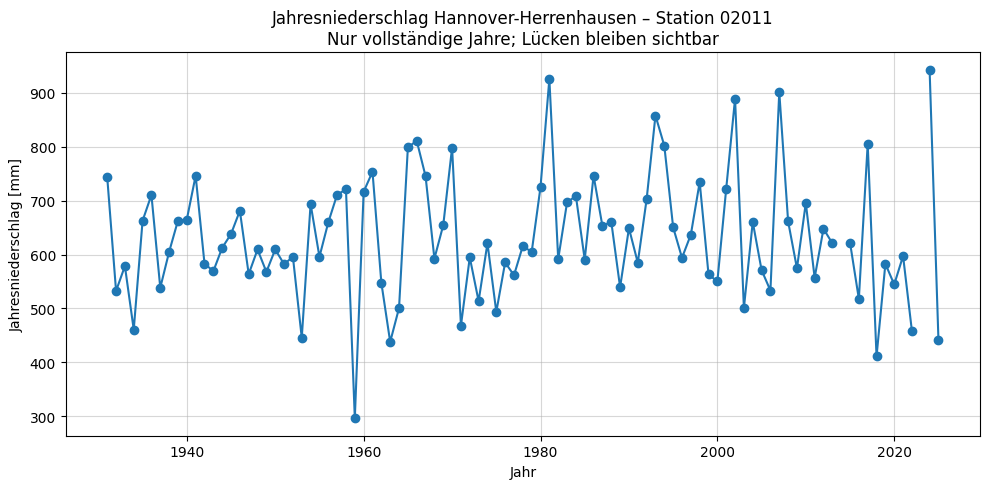

In [19]:
plt.figure(figsize=(10, 5))
# Die Tabelle enthält alle Kalenderjahre; fehlende Summen unterbrechen die Linie.
plt.plot(jahressumme["jahr"], jahressumme["niederschlag_mm"], marker="o")
plt.xlabel("Jahr")
plt.ylabel("Jahresniederschlag [mm]")
plt.title(f"Jahresniederschlag {ORT} – Station {STATION_ID}\nNur vollständige Jahre; Lücken bleiben sichtbar")
plt.grid(True, alpha=0.5)
plt.tight_layout()
if GRAFIKEN_SPEICHERN:
    fig_ordner.mkdir(parents=True, exist_ok=True)
    plt.savefig(fig_ordner / f"jahresniederschlag_{ortskennung}_{STATION_ID}.pdf", bbox_inches="tight")
plt.show()


## 13. Monatsverlauf ausgewählter Jahre

Hier werden vollständige Monate verglichen. Auch ein unvollständiges Jahr kann einzelne
vollständige Monate enthalten. Unvollständige Monate erscheinen als Lücken; ihre
Teilsummen werden nicht als vollständige Monatssummen dargestellt.


Vollständigkeit und Summen der ausgewählten Monate:


,jahr,monat,tage_gueltig,tage_erwartet,vollstaendig,niederschlag_mm
348,1960,1,31,31,True,56.8
349,1960,2,29,29,True,31.9
350,1960,3,31,31,True,15.6
351,1960,4,30,30,True,41.7
352,1960,5,31,31,True,79.6
353,1960,6,30,30,True,24.2
354,1960,7,31,31,True,48.7
355,1960,8,31,31,True,135.4
356,1960,9,30,30,True,24.8
357,1960,10,31,31,True,100.9


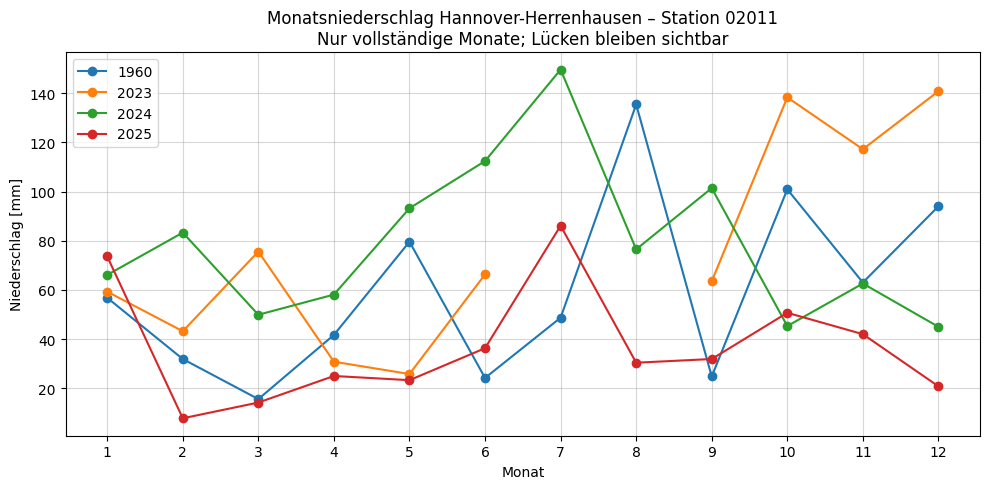

In [20]:
jahre_vergleich = [1960, 2023, 2024, 2025]
vergleich = monatssumme.loc[monatssumme["jahr"].isin(jahre_vergleich)].copy()
print("Vollständigkeit und Summen der ausgewählten Monate:")
display(vergleich[["jahr", "monat", "tage_gueltig", "tage_erwartet", "vollstaendig", "niederschlag_mm"]])

plt.figure(figsize=(10, 5))
for jahr in jahre_vergleich:
    daten = vergleich.loc[vergleich["jahr"] == jahr].set_index("monat").reindex(range(1, 13))
    if daten["niederschlag_mm"].notna().any():
        plt.plot(daten.index, daten["niederschlag_mm"], marker="o", label=str(jahr))
    else:
        print(f"{jahr}: keine vollständigen Monatssummen verfügbar.")
plt.xlabel("Monat")
plt.ylabel("Niederschlag [mm]")
plt.title(f"Monatsniederschlag {ORT} – Station {STATION_ID}\nNur vollständige Monate; Lücken bleiben sichtbar")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.5)
if plt.gca().lines:
    plt.legend()
plt.tight_layout()
if GRAFIKEN_SPEICHERN:
    fig_ordner.mkdir(parents=True, exist_ok=True)
    plt.savefig(fig_ordner / f"monatsvergleich_{ortskennung}_{STATION_ID}.pdf", bbox_inches="tight")
plt.show()


## 14. Tage mit mindestens 20 mm Niederschlag pro Jahr

Diese Tageszählung wird ebenfalls nur für vollständig belegte Jahre verglichen.
Bei fehlenden Messwerten wissen wir nicht, ob darunter weitere Tage über der Schwelle
liegen. Eine fehlende Jahreszählung darf deshalb nicht als null interpretiert werden.


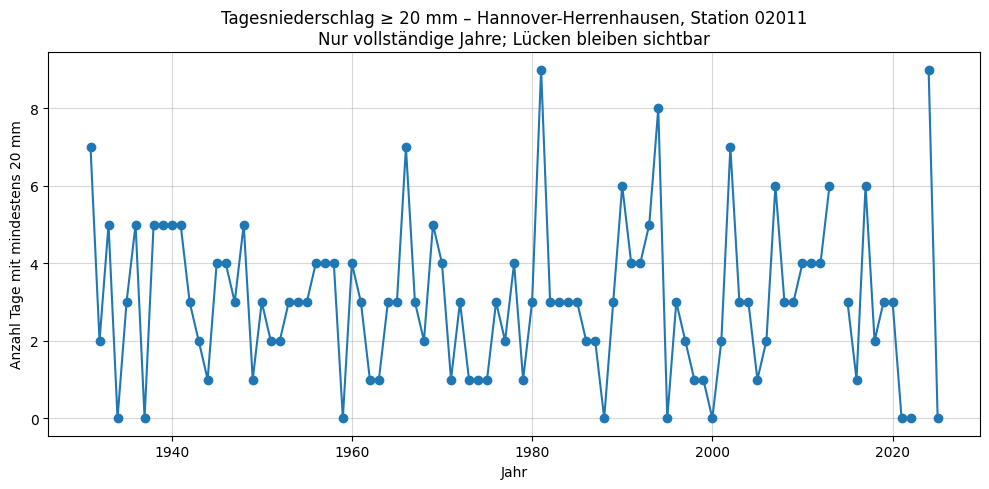

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(
    starkregen_pro_jahr["jahr"],
    starkregen_pro_jahr["anzahl_starkregentage_20mm"].to_numpy(dtype=float, na_value=float("nan")),
    marker="o",
)
plt.xlabel("Jahr")
plt.ylabel("Anzahl Tage mit mindestens 20 mm")
plt.title(f"Tagesniederschlag ≥ 20 mm – {ORT}, Station {STATION_ID}\nNur vollständige Jahre; Lücken bleiben sichtbar")
plt.grid(True, alpha=0.5)
plt.tight_layout()
if GRAFIKEN_SPEICHERN:
    fig_ordner.mkdir(parents=True, exist_ok=True)
    plt.savefig(fig_ordner / f"tage_ab_20mm_{ortskennung}_{STATION_ID}.pdf", bbox_inches="tight")
plt.show()


## 15. Rückblick

Bevor die erste Grafik entstehen konnte, waren mehrere Schritte notwendig:
- eine Forschungsfrage präzisieren,
- eine verlässliche Quelle wählen,
- Metadaten lesen,
- eine geeignete Station identifizieren,
- verfügbare Dateien prüfen,
- Daten laden, bereinigen und zusammenführen,
- fehlende Datumszeilen und Messwerte durch Kalendervergleich erkennen,
- entscheiden, welche Zeiträume für einen Vergleich vollständig genug sind,
- erst danach Berechnungen und Visualisierungen erstellen.

Gerade darin zeigt sich ein wichtiger Unterschied zwischen Realdaten und bereits aufbereiteten Unterrichtstabellen:
Der Datensatz liegt nicht einfach vor, sondern muss zunächst erschlossen werden.

Python steht dabei nicht im Zentrum als Selbstzweck.
Es hilft vielmehr, die komplexen und wiederkehrenden Schritte der Verarbeitung transparent und reproduzierbar zu automatisieren.
Auch der Export nach Excel kann sinnvoll sein, weil dort in einer vertrauten Umgebung sichtbar wird,
welche Vorarbeit nötig ist, damit Realdaten überhaupt rechnerisch bearbeitbar werden.

## 16. Von Jahressummen zu Rekorden und Anstiegen

Wir untersuchen die **Summe des Niederschlags in einem Kalenderjahr**. Damit schließt die
Modellierung direkt an die Jahresgrafik an. Nur vollständig belegte Jahre werden verwendet.

- Ein **Rekord** liegt vor, wenn eine Jahressumme größer ist als alle vorhergehenden
  Jahressummen der ausgewählten Reihe. Das erste ausgewählte Jahr zählt als Rekord.
  Ein gleich großer Wert ist kein neuer Rekord. Über mögliche Rekorde in ausgeschlossenen
  Jahren können wir nichts sagen.
- Ein **Anstieg** liegt vor, wenn die Jahressumme größer ist als die des unmittelbaren
  Kalender-Vorjahres. Beide Jahre müssen vollständig vorliegen. Über Lücken hinweg wird
  nicht verglichen; ein gleich großer Wert zählt nicht als Anstieg.

**Vor der Berechnung:** Sucht in der Jahresgrafik mögliche Rekordjahre. Können zwei Reihen
mit derselben Zahl von Rekorden unterschiedlich viele Anstiege haben?

Die verwendeten Tagesdaten geben Niederschlag in Zehntelmillimetern an. Deshalb werden
Jahressummen für die Vergleiche in ganze Zehntelmillimeter umgerechnet. So können winzige
Rechenabweichungen bei Dezimalzahlen keine scheinbaren Rekorde oder Anstiege erzeugen.
Gleiche Messwerte bleiben gleich; sie werden nicht durch verschiedene Ränge ersetzt.

In [22]:
modellreihe = (
    jahressumme_voll[["jahr", "niederschlag_mm"]]
    .sort_values("jahr").reset_index(drop=True).copy()
)
modellreihe["jahressumme_zehntel_mm"] = np.rint(
    modellreihe["niederschlag_mm"].to_numpy() * 10
).astype(np.int64)
modellreihe["jahressumme_mm"] = modellreihe["jahressumme_zehntel_mm"] / 10
modellreihe = modellreihe.drop(columns="niederschlag_mm")

jahre = modellreihe["jahr"].to_numpy(dtype=int)
werte = modellreihe["jahressumme_zehntel_mm"].to_numpy(dtype=np.int64)
# Diese Maske bleibt bei jeder Zufallsanordnung unverändert.
vorjahrespaare = np.diff(jahre) == 1


def merkmale_der_reihe(folge, paare):
    """Dieselben strengen Vergleiche für Beobachtung und Simulation."""
    folge = np.asarray(folge)
    paare = np.asarray(paare, dtype=bool)
    if len(paare) != max(len(folge) - 1, 0):
        raise ValueError("Die Paarmaske muss zu den Positionen der Jahresreihe passen.")
    if len(folge) == 0:
        return np.array([], dtype=bool), np.array([], dtype=bool)
    rekorde = np.r_[True, folge[1:] > np.maximum.accumulate(folge[:-1])]
    anstiege = (folge[1:] > folge[:-1]) & paare
    return rekorde, anstiege


rekordmaske, anstiegsmaske = merkmale_der_reihe(werte, vorjahrespaare)
modellreihe["rekord"] = rekordmaske
modellreihe["vorjahresvergleich_moeglich"] = np.r_[False, vorjahrespaare] if len(werte) else []
modellreihe["anstieg"] = pd.Series(
    np.r_[False, anstiegsmaske] if len(werte) else [], dtype="boolean"
).where(modellreihe["vorjahresvergleich_moeglich"])

beobachtete_rekorde = int(rekordmaske.sum())
beobachtete_anstiege = int(anstiegsmaske.sum())
print("Vollständige Jahre:", len(werte))
print("Vergleiche mit dem unmittelbaren Vorjahr:", int(vorjahrespaare.sum()))
print("Rekorde in der ausgewählten Reihe (erstes Jahr zählt mit):", beobachtete_rekorde)
print("Anstiege gegenüber dem unmittelbaren Vorjahr:", beobachtete_anstiege)
print("Rekordjahre:")
display(modellreihe.loc[modellreihe["rekord"], ["jahr", "jahressumme_mm"]])
print("Letzte Jahre; leeres Anstiegsfeld bedeutet: kein zulässiger Vorjahresvergleich.")
display(modellreihe.tail(15))

Vollständige Jahre: 93
Vergleiche mit dem unmittelbaren Vorjahr: 90
Rekorde in der ausgewählten Reihe (erstes Jahr zählt mit): 7
Anstiege gegenüber dem unmittelbaren Vorjahr: 48
Rekordjahre:


,jahr,jahressumme_mm
0,1931,743.8
10,1941,746.4
30,1961,753.7
34,1965,798.8
35,1966,811.3
50,1981,926.1
91,2024,943.4


Letzte Jahre; leeres Anstiegsfeld bedeutet: kein zulässiger Vorjahresvergleich.


,jahr,jahressumme_zehntel_mm,jahressumme_mm,rekord,vorjahresvergleich_moeglich,anstieg
78,2009,5744,574.4,False,True,False
79,2010,6958,695.8,False,True,True
80,2011,5569,556.9,False,True,False
81,2012,6479,647.9,False,True,True
82,2013,6209,620.9,False,True,False
83,2015,6223,622.3,False,False,<NA>
84,2016,5176,517.6,False,True,False
85,2017,8052,805.2,False,True,True
86,2018,4108,410.8,False,True,False
87,2019,5828,582.8,False,True,True


## 17. Was bedeutet hier eine zufällige Anordnung?

**Modellfrage:** Welche Anzahlen von Rekorden und Anstiegen entstehen, wenn wir die
vorhandenen vollständigen Jahressummen zufällig auf die ausgewählten Jahrespositionen verteilen?

Dabei bleiben die Messwerte einschließlich gleicher Werte, die ausgewählten Kalenderjahre
und die Lücken unverändert. Nur die Zuordnung der Werte zu den Jahren wird vertauscht.
Wir verwenden für Daten und Simulation dieselbe Zählfunktion und dieselbe Vorjahresmaske.
Eine fehlende Jahressumme wird durch die Simulation nicht ergänzt.

Das Modell behandelt alle Anordnungen der vorhandenen Werte als gleichberechtigt. Das ist
eine Annahme über die zeitliche Austauschbarkeit der Werte, keine festgestellte Eigenschaft
von Wetterdaten. Zeitliche Abhängigkeiten, Veränderungen der Messbedingungen oder eine
langfristige Entwicklung werden damit nicht nachgebildet. Die Auswahl der vollständigen
Jahre wird als gegeben behandelt; mögliche Ursachen der Datenlücken werden nicht modelliert.

**Erkundungsauftrag:** Vergleicht die beobachtete Reihe mit einer Zufallsanordnung.
Welche Eigenschaften bleiben gleich, welche ändern sich? Verfolgt insbesondere die Lücken
zwischen den ausgewählten Jahren.

Beispielanordnung – Rekorde: 6 Anstiege: 43


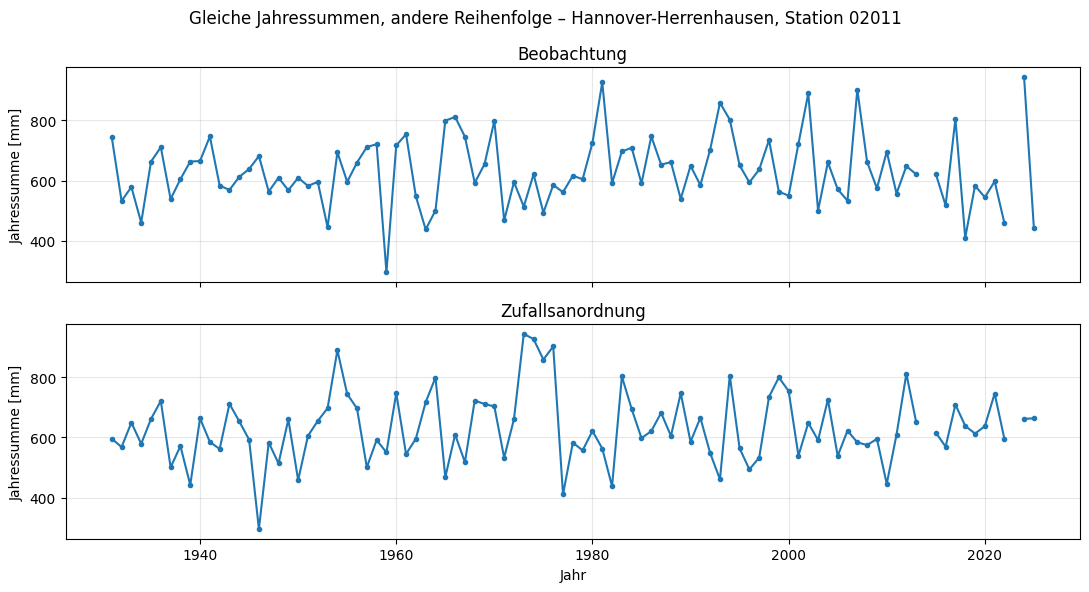

In [23]:
# Die Beispielanordnung und die große Simulation verwenden getrennte Zufallsgeneratoren.
# So beeinflusst ein erneuter Aufruf der Beispielzelle nicht die Simulation.
beispielwerte = np.random.default_rng(SEED).permutation(werte)
beispiel_rekorde, beispiel_anstiege = merkmale_der_reihe(beispielwerte, vorjahrespaare)
print("Beispielanordnung – Rekorde:", int(beispiel_rekorde.sum()),
      "Anstiege:", int(beispiel_anstiege.sum()))

if len(werte):
    beispieltabelle = pd.DataFrame({
        "jahr": jahre, "Beobachtung": werte / 10, "Zufallsanordnung": beispielwerte / 10
    }).set_index("jahr").reindex(jahressumme["jahr"])
    fig, achsen = plt.subplots(2, 1, figsize=(11, 6), sharex=True, sharey=True)
    for ax, name in zip(achsen, ["Beobachtung", "Zufallsanordnung"]):
        ax.plot(beispieltabelle.index, beispieltabelle[name], marker="o", markersize=3)
        ax.set_title(name)
        ax.set_ylabel("Jahressumme [mm]")
        ax.grid(True, alpha=0.3)
    achsen[-1].set_xlabel("Jahr")
    fig.suptitle(f"Gleiche Jahressummen, andere Reihenfolge – {ORT}, Station {STATION_ID}")
    fig.tight_layout()
    if GRAFIKEN_SPEICHERN:
        fig_ordner.mkdir(parents=True, exist_ok=True)
        fig.savefig(fig_ordner / f"zufallsanordnung_{ortskennung}_{STATION_ID}.pdf", bbox_inches="tight")
    plt.show()

## 18. Viele Zufallsanordnungen untersuchen

Wir wiederholen das zufällige Vertauschen und zählen jedes Mal Rekorde und Anstiege.
Der Startwert `SEED` macht den Versuch bei gleichen Daten und gleicher Softwareumgebung
wiederholbar. Die Zahl der Wiederholungen lässt sich oben mit `SIMULATIONEN` ändern.

Die Simulation permutiert die tatsächlichen Werte mit ihren Gleichständen. Deshalb werden
hier keine Formeln für Permutationen ausschließlich verschiedener Werte eingesetzt.
Auch die Zahl der zulässigen Vorjahresvergleiche wird aus der Jahresauswahl bestimmt.

**Vorhersage:** In welchem Bereich erwartet ihr die beiden Anzahlen? Überlegt zunächst,
warum die Zahl der Anstiege allein keinen unmittelbaren Maßstab für die Größe einer
Niederschlagsänderung liefert.

In [24]:
if not isinstance(SIMULATIONEN, (int, np.integer)) or isinstance(SIMULATIONEN, bool) or SIMULATIONEN < 2:
    raise ValueError("SIMULATIONEN muss eine ganze Zahl von mindestens 2 sein.")

simulation = pd.DataFrame(columns=["rekorde", "anstiege"], dtype=int)
vergleichstabelle = pd.DataFrame()
modell_auswertbar = len(werte) >= 2 and vorjahrespaare.any()

if modell_auswertbar:
    rng = np.random.default_rng(SEED)
    ergebnisse = np.empty((SIMULATIONEN, 2), dtype=int)
    for durchlauf in range(SIMULATIONEN):
        zufallswerte = rng.permutation(werte)
        r, a = merkmale_der_reihe(zufallswerte, vorjahrespaare)
        ergebnisse[durchlauf] = (r.sum(), a.sum())
    simulation = pd.DataFrame(ergebnisse, columns=["rekorde", "anstiege"])

    zeilen = []
    for merkmal, beobachtet in [("rekorde", beobachtete_rekorde), ("anstiege", beobachtete_anstiege)]:
        s = simulation[merkmal]
        zeilen.append({
            "merkmal": merkmal,
            "beobachtet": beobachtet,
            "simulierter_mittelwert": s.mean(),
            "simulierte_varianz": s.var(ddof=1),
            "quantil_2_5_prozent": s.quantile(0.025, interpolation="nearest"),
            "quantil_97_5_prozent": s.quantile(0.975, interpolation="nearest"),
            "anteil_mindestens_beobachtet": s.ge(beobachtet).mean(),
        })
    vergleichstabelle = pd.DataFrame(zeilen)
    display(vergleichstabelle.round(4))
else:
    print("Für diesen Vergleich werden mindestens zwei vollständige Jahre und ein zulässiges Vorjahrespaar benötigt.")

,merkmal,beobachtet,simulierter_mittelwert,simulierte_varianz,quantil_2_5_prozent,quantil_97_5_prozent,anteil_mindestens_beobachtet
0,rekorde,7,5.1144,3.4551,2,9,0.2191
1,anstiege,48,44.9823,7.9672,39,50,0.1839


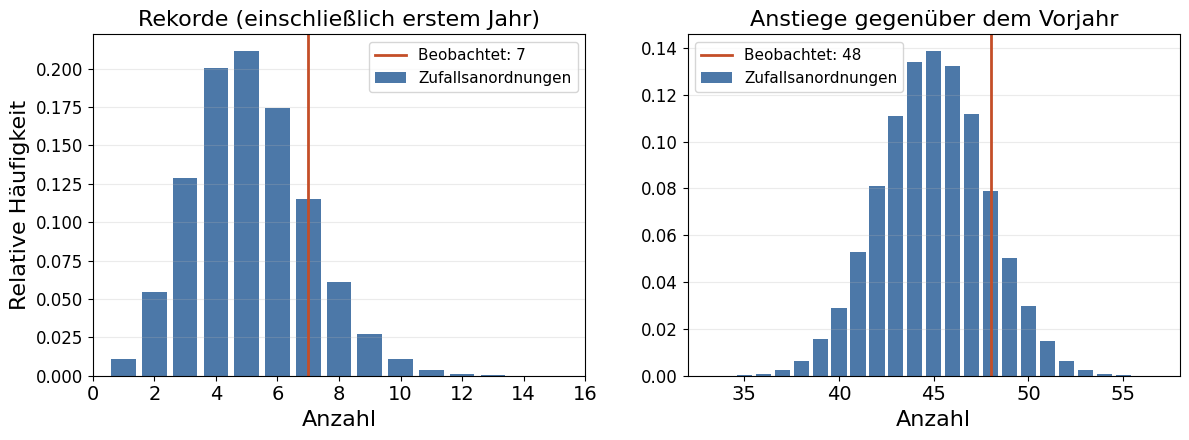

In [25]:
if modell_auswertbar:
    fig, achsen = plt.subplots(1, 2, figsize=(12, 4.5))
    for ax, merkmal, titel, beobachtet in [
        (achsen[0], "rekorde", "Rekorde (einschließlich erstem Jahr)", beobachtete_rekorde),
        (achsen[1], "anstiege", "Anstiege gegenüber dem Vorjahr", beobachtete_anstiege),
    ]:
        haeufigkeiten = simulation[merkmal].value_counts(normalize=True).sort_index()
        ax.bar(haeufigkeiten.index, haeufigkeiten.values, color="#4c78a8", label="Zufallsanordnungen")
        ax.axvline(beobachtet, color="#c44e28", linewidth=2,
                   label=f"Beobachtet: {beobachtet}")
        ax.set_title(titel,fontsize=16)
        ax.set_xlabel("Anzahl",fontsize=16)
       # ax.set_ylabel("Relative Häufigkeit",fontsize=16)
        ax.set_xlim(min(haeufigkeiten.index.min(), beobachtet) - 1,
                    max(haeufigkeiten.index.max(), beobachtet) + 1)
        ax.legend(fontsize=11)
        ax.grid(axis="y", alpha=0.25)
        ax.xaxis.set_tick_params(labelsize=14)
        ax.yaxis.set_tick_params(labelsize=12)
   # fig.suptitle(f"Jahressummen: {len(werte)} Jahre, {int(vorjahrespaare.sum())} Vorjahrespaare, "
    #             f"{SIMULATIONEN:,} Simulationen, Seed {SEED}")
    achsen[0].set_ylabel("Relative Häufigkeit", fontsize=16)
    fig.tight_layout(w_pad=4)
   # if GRAFIKEN_SPEICHERN:
    fig_ordner.mkdir(parents=True, exist_ok=True)
    fig.savefig(fig_ordner / f"simulation_jahressummen_{ortskennung}_{STATION_ID}.pdf", bbox_inches="tight")
    plt.show()

## 19. Die Beobachtung im Modell einordnen

Die senkrechten Linien markieren die beobachteten Anzahlen. Die Balken zeigen, wie häufig
die jeweiligen Anzahlen bei zufälliger Anordnung derselben Jahressummen auftraten.

- Der simulierte Mittelwert beschreibt die durchschnittliche Anzahl im Vergleichsmodell.
- Die beiden Quantile begrenzen einen mittleren Bereich der simulierten Anzahlen.
  Wegen der ganzzahligen Werte enthält dieser Bereich nicht zwingend genau 95 Prozent.
  Er ist kein Konfidenzintervall für einen Klimatrend.
- `anteil_mindestens_beobachtet` ist der Anteil der Simulationen, in denen die jeweilige
  Anzahl mindestens so groß wie die beobachtete Anzahl war. Diese gerichtete Kennzahl
  betrachtet ausdrücklich **hohe** Anzahlen, nicht Auffälligkeit in beiden Richtungen.
  Sie ist eine Simulationsschätzung und keine Wahrscheinlichkeit dafür, dass das Modell wahr ist.

**Auswertungsaufträge:**

1. Liegen die beobachteten Anzahlen in häufig oder selten auftretenden Bereichen?
   Begründet eure Antwort getrennt für Rekorde und Anstiege mit Grafik und Tabelle.
2. Verändert den Seed. Was bleibt ähnlich, was schwankt? Was bewirkt eine größere
   Zahl von Wiederholungen?
3. Welche Aussagen erlauben diese zwei Kennzahlen nicht? Bezieht dabei Höhe und
   zeitliche Verteilung der Niederschläge sowie die ausgeschlossenen Jahre ein.

Ein unauffälliger Wert beweist nicht, dass keine Veränderung vorliegt. Ein auffälliger Wert
weist zunächst auf eine Abweichung vom gewählten Vergleichsmodell hin und erklärt keine
Ursache. Insbesondere liefert diese einzelne Stationsreihe allein keinen Nachweis für oder
gegen eine bestimmte klimatische Entwicklung.

In [26]:
# Der Export dokumentiert die exakte Jahresauswahl und damit auch die Lage der Lücken.
datenkennung = hashlib.sha256(
    modellreihe[["jahr", "jahressumme_zehntel_mm"]].to_csv(index=False).encode("utf-8")
).hexdigest()
modelldokumentation = pd.DataFrame([{
    "station": STATION_ID,
    "stationsname": stationsname,
    "quellen_sha256": "; ".join(quellennachweis["sha256"]),
    "abrufe_utc": "; ".join(quellennachweis["abruf_utc"]),
    "qualitaetsregel": "Kein QN_6-Filter; Codes separat dokumentiert",
    "messgroesse": "Jahressumme in mm; Vergleich in ganzen Zehntelmillimetern",
    "auswahlregel": "Alle Kalendertage mit gültigem Wert",
    "rekordregel": "Streng größer als alle vorigen ausgewählten Werte; erstes Jahr zählt",
    "anstiegsregel": "Streng größer; nur direkte Kalender-Vorjahrespaare",
    "vollstaendige_jahre": len(werte),
    "vorjahrespaare": int(vorjahrespaare.sum()),
    "simulationen_ausgefuehrt": len(simulation),
    "seed": SEED,
    "datenstand_bis": combined["datum"].max().strftime("%Y-%m-%d"),
    "numpy_version": np.__version__,
    "datenkennung_sha256": datenkennung,
}])
if EXCEL_EXPORT:
    excel_ordner.mkdir(parents=True, exist_ok=True)
    dateiname = excel_ordner / f"modellierung_jahressummen_{ortskennung}_{STATION_ID}.xlsx"
    with pd.ExcelWriter(dateiname, engine="openpyxl") as writer:
        exportiere_erlaeuterungen(writer)
        exportiere_jahressummen_einstieg(writer)
        datensteckbrief.to_excel(writer, sheet_name="Datensteckbrief", index=False)
        quellennachweis.to_excel(writer, sheet_name="Quellennachweis", index=False)
        qn_legende.to_excel(writer, sheet_name="QN_Legende", index=False)
        for art, tabelle in metadaten_tabellen.items():
            tabelle.to_excel(writer, sheet_name=f"Metadaten_{art}", index=False)
        qualitaet_modellauswahl.to_excel(writer, sheet_name="Qualitaet_Modellauswahl", index=False)
        modellreihe.to_excel(writer, sheet_name="Verwendete_Jahressummen", index=False)
        vergleichstabelle.to_excel(writer, sheet_name="Modellvergleich", index=False)
        modelldokumentation.to_excel(writer, sheet_name="Dokumentation", index=False)
        for merkmal in ["rekorde", "anstiege"]:
            verteilung = simulation[merkmal].value_counts().sort_index().rename_axis("anzahl").reset_index(name="haeufigkeit")
            verteilung.to_excel(writer, sheet_name=f"Verteilung_{merkmal}", index=False)
    print("Exportiert:", dateiname.resolve())

Exportiert: /Users/reimund/Documents/Arbeit/Projekte/BigData/src/notebooks/ausgabe/excel/modellierung_jahressummen_Hannover-Herrenhausen_02011.xlsx
